# Bacterial Growth Media Optimization: Round Analysis

Analysis of three rounds of bacterial growth media optimization:

- **Round 1** (`PLT12V3H4WNRSR6CWJ7A72ODORU7EI`): Cell volume screen using baseline *Novel Bio NBxCyclone* media. Tested media volumes from 100–190 µL (i.e., 100–10 µL of cells) in a 200 µL total volume, with **3 replicates per condition**.
- **Round 2** (`PLT1RLOSUISCDIHOFWDWTLWCUPCOLQ`): DOE-style screen testing three media families — **Semi-Defined (SD)**, **High Buffer Defined (HB)**, and **LB-based (LB)** — each with varied reagent compositions, alongside a Novel Bio Cyclone baseline. **1 replicate per condition**.
- **Round 3** (`PLT1RQR2P5DESEEHSKOIUQCNAXH3RA`): Two-part plate. **Row B (BayBE)**: BayBE-proposed exploitation of top R2 HB and SD conditions with refined reagent volumes. **Row D (Mechanistic)**: Elnora-designed conditions testing mechanistic hypotheses — nitrogen maximization, metal supplementation, glycerol carbon sources, and iron/citrate additions. **1 replicate per condition**.

In [20]:
import pandas as pd
import numpy as np
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

theme_set(theme_bw(base_size=12))

MEDIA_COLORS = {
    'Baseline (Novel Bio Cyclone)': '#9b59b6',
    'Semi-Defined':                 '#2ecc71',
    'High Buffer Defined':          '#e74c3c',
    'LB-based':                     '#3498db',
    'Defined Glycerol':             '#f39c12',
}

In [21]:
BASE = '../data'

# Round 1 – cell volume screen
r1_growth = pd.read_csv(f'{BASE}/PLT12V3H4WNRSR6CWJ7A72ODORU7EI_growth.csv')
r1_raw    = pd.read_csv(f'{BASE}/PLT12V3H4WNRSR6CWJ7A72ODORU7EI.csv')
r1_reps   = pd.read_csv(f'{BASE}/PLT12V3H4WNRSR6CWJ7A72ODORU7EI_replicates.csv')

# Round 2 – media DOE
r2_growth = pd.read_csv(f'{BASE}/PLT1RLOSUISCDIHOFWDWTLWCUPCOLQ_growth.csv')
r2_raw    = pd.read_csv(f'{BASE}/PLT1RLOSUISCDIHOFWDWTLWCUPCOLQ.csv')

# Round 3 – BayBE exploitation (Row B) + mechanistic hypotheses (Row D)
r3_growth = pd.read_csv(f'{BASE}/PLT1RQR2P5DESEEHSKOIUQCNAXH3RA_growth.csv')
r3_raw    = pd.read_csv(f'{BASE}/PLT1RQR2P5DESEEHSKOIUQCNAXH3RA.csv')

print(f"Round 1: {len(r1_growth)} wells | {r1_growth['condition_id'].nunique()} conditions"
      f" | growth rate range: {r1_growth['growth_rate_per_hr'].min():.3f} – {r1_growth['growth_rate_per_hr'].max():.3f} hr⁻¹")
print(f"Round 2: {len(r2_growth)} wells | {r2_growth['condition_id'].nunique()} conditions"
      f" | growth rate range: {r2_growth['growth_rate_per_hr'].min():.3f} – {r2_growth['growth_rate_per_hr'].max():.3f} hr⁻¹")
print(f"Round 3: {len(r3_growth)} wells | {r3_growth['condition_id'].nunique()} conditions"
      f" | growth rate range: {r3_growth['growth_rate_per_hr'].min():.3f} – {r3_growth['growth_rate_per_hr'].max():.3f} hr⁻¹")

Round 1: 30 wells | 10 conditions | growth rate range: 0.320 – 2.893 hr⁻¹
Round 2: 10 wells | 10 conditions | growth rate range: 3.020 – 4.143 hr⁻¹
Round 3: 13 wells | 13 conditions | growth rate range: 1.259 – 3.320 hr⁻¹


---
## Section 1: Growth Rate Distribution by Round

Overview of the growth rate landscape across both rounds.

Round 1 median growth rate: 0.699 hr⁻¹
Round 2 median growth rate: 3.351 hr⁻¹
Round 3 median growth rate: 2.748 hr⁻¹
Fold improvement R1 → R2 (median): 4.80×
Fold improvement R1 → R3 (median): 3.93×


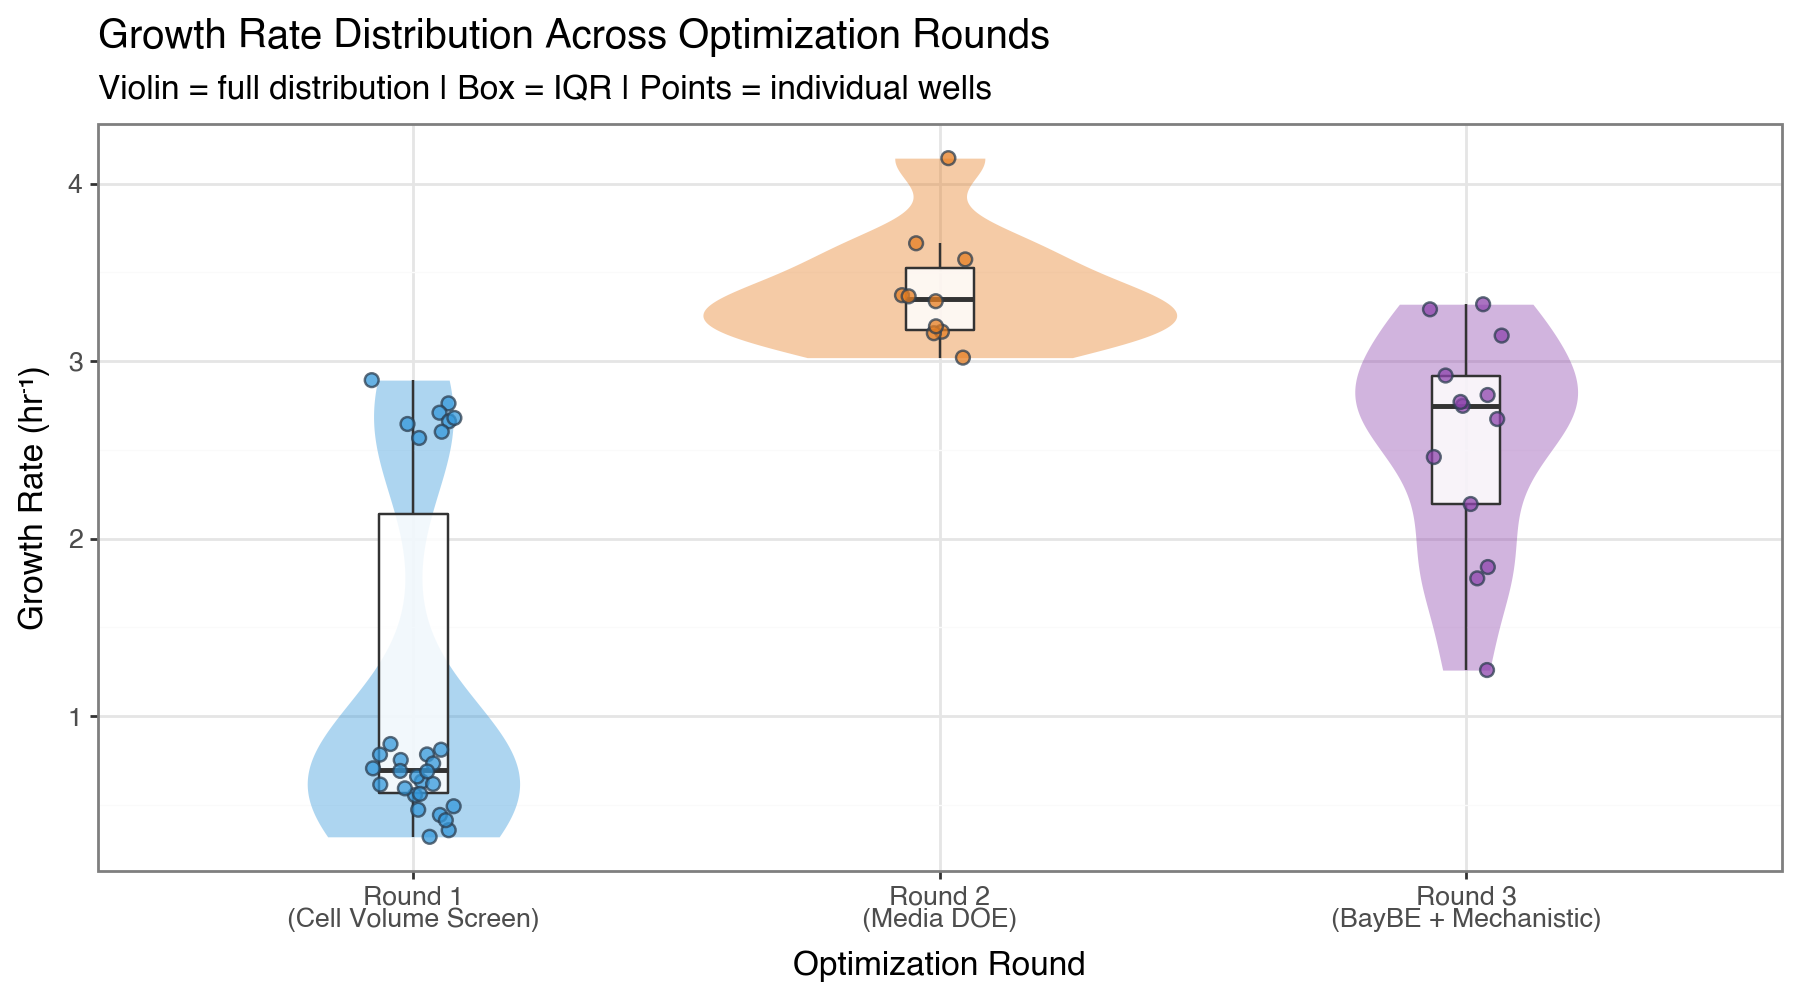

In [22]:
r1_growth['round'] = 'Round 1\n(Cell Volume Screen)'
r2_growth['round'] = 'Round 2\n(Media DOE)'
r3_growth['round'] = 'Round 3\n(BayBE + Mechanistic)'

combined = pd.concat([
    r1_growth[['growth_rate_per_hr', 'round']],
    r2_growth[['growth_rate_per_hr', 'round']],
    r3_growth[['growth_rate_per_hr', 'round']]
], ignore_index=True)

r1_med = r1_growth['growth_rate_per_hr'].median()
r2_med = r2_growth['growth_rate_per_hr'].median()
r3_med = r3_growth['growth_rate_per_hr'].median()
print(f"Round 1 median growth rate: {r1_med:.3f} hr⁻¹")
print(f"Round 2 median growth rate: {r2_med:.3f} hr⁻¹")
print(f"Round 3 median growth rate: {r3_med:.3f} hr⁻¹")
print(f"Fold improvement R1 → R2 (median): {r2_med / r1_med:.2f}×")
print(f"Fold improvement R1 → R3 (median): {r3_med / r1_med:.2f}×")

(
    ggplot(combined, aes(x='round', y='growth_rate_per_hr', fill='round'))
    + geom_violin(alpha=0.4, color='none')
    + geom_boxplot(width=0.13, outlier_alpha=0, fill='white', alpha=0.85)
    + geom_jitter(width=0.08, alpha=0.75, size=2.3, color='#2c3e50')
    + scale_fill_manual(values={
        'Round 1\n(Cell Volume Screen)':  '#3498db',
        'Round 2\n(Media DOE)':           '#e67e22',
        'Round 3\n(BayBE + Mechanistic)': '#8e44ad',
    })
    + labs(
        title='Growth Rate Distribution Across Optimization Rounds',
        subtitle='Violin = full distribution | Box = IQR | Points = individual wells',
        x='Optimization Round',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(legend_position='none', figure_size=(9, 5))
)

---
## Section 2: Round 1 Deep Dive – Cell Volume Screen

In Round 1, all wells used the same Novel Bio NBxCyclone media but varied the **media volume** (100–190 µL), which inversely controls the **cell seeding volume** (100–10 µL). Total well volume was fixed at 200 µL.

In [23]:
# reagent_volume_uL in Round 1 is the media volume (single reagent per well)
r1_growth['media_vol_uL'] = r1_growth['reagent_volume_uL']
r1_growth['cell_vol_uL']  = 200 - r1_growth['media_vol_uL']

# Per-condition summary (mean ± SD across 3 replicates)
r1_summary = (
    r1_growth
    .groupby('media_vol_uL')
    .agg(
        mean_gr    = ('growth_rate_per_hr',   'mean'),
        sd_gr      = ('growth_rate_per_hr',   'std'),
        mean_od    = ('max_absorbance_OD600',  'mean'),
        cell_vol   = ('cell_vol_uL',           'first')
    )
    .reset_index()
)
r1_summary['ymin'] = r1_summary['mean_gr'] - r1_summary['sd_gr']
r1_summary['ymax'] = r1_summary['mean_gr'] + r1_summary['sd_gr']

r1_summary.head(10)

,media_vol_uL,mean_gr,sd_gr,mean_od,cell_vol,ymin,ymax
0,100.0,1.264764,1.300765,0.970000,100.0,-0.036001,2.565529
1,110.0,0.496937,0.055748,0.635800,90.0,0.441189,0.552685
2,120.0,0.474599,0.117758,0.765167,80.0,0.356841,0.592357
3,130.0,0.753094,0.108968,0.747633,70.0,0.644126,0.862061
4,140.0,0.685901,0.023536,0.762800,60.0,0.662365,0.709437
5,150.0,0.718835,0.136596,0.772300,50.0,0.582240,0.855431
6,160.0,0.725130,0.033031,0.718133,40.0,0.692100,0.758161
7,170.0,1.204797,1.285609,0.560900,30.0,-0.080813,2.490406
8,180.0,2.646014,0.072422,0.297333,20.0,2.573592,2.718436
9,190.0,2.713531,0.156873,0.293000,10.0,2.556657,2.870404


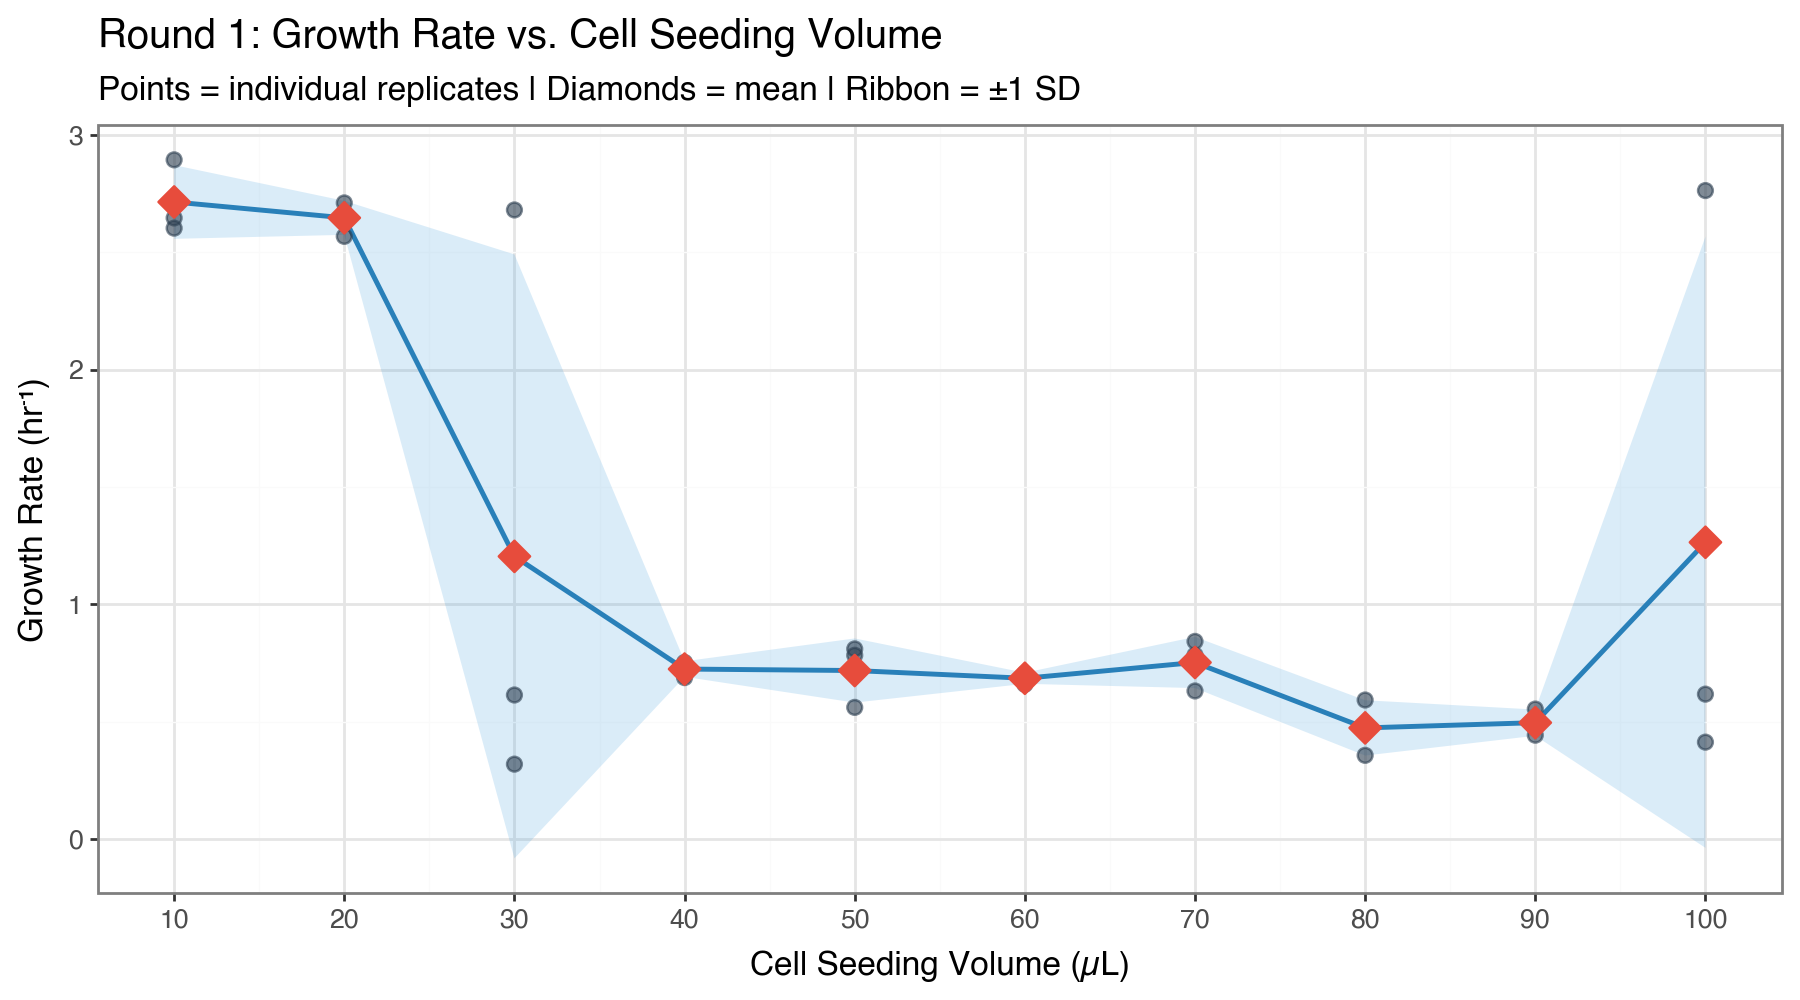

In [24]:
# Figure 2: Growth rate vs. cell seeding volume
(
    ggplot()
    + geom_ribbon(
        r1_summary,
        aes(x='cell_vol', ymin='ymin', ymax='ymax'),
        alpha=0.18, fill='#3498db'
    )
    + geom_line(
        r1_summary,
        aes(x='cell_vol', y='mean_gr'),
        color='#2980b9', size=1.0
    )
    + geom_point(
        r1_growth,
        aes(x='cell_vol_uL', y='growth_rate_per_hr'),
        color='#2c3e50', alpha=0.6, size=2.5
    )
    + geom_point(
        r1_summary,
        aes(x='cell_vol', y='mean_gr'),
        color='#e74c3c', size=4, shape='D'
    )
    + scale_x_continuous(breaks=list(range(10, 110, 10)))
    + labs(
        title='Round 1: Growth Rate vs. Cell Seeding Volume',
        subtitle='Points = individual replicates | Diamonds = mean | Ribbon = ±1 SD',
        x='Cell Seeding Volume (µL)',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(figure_size=(9, 5))
)

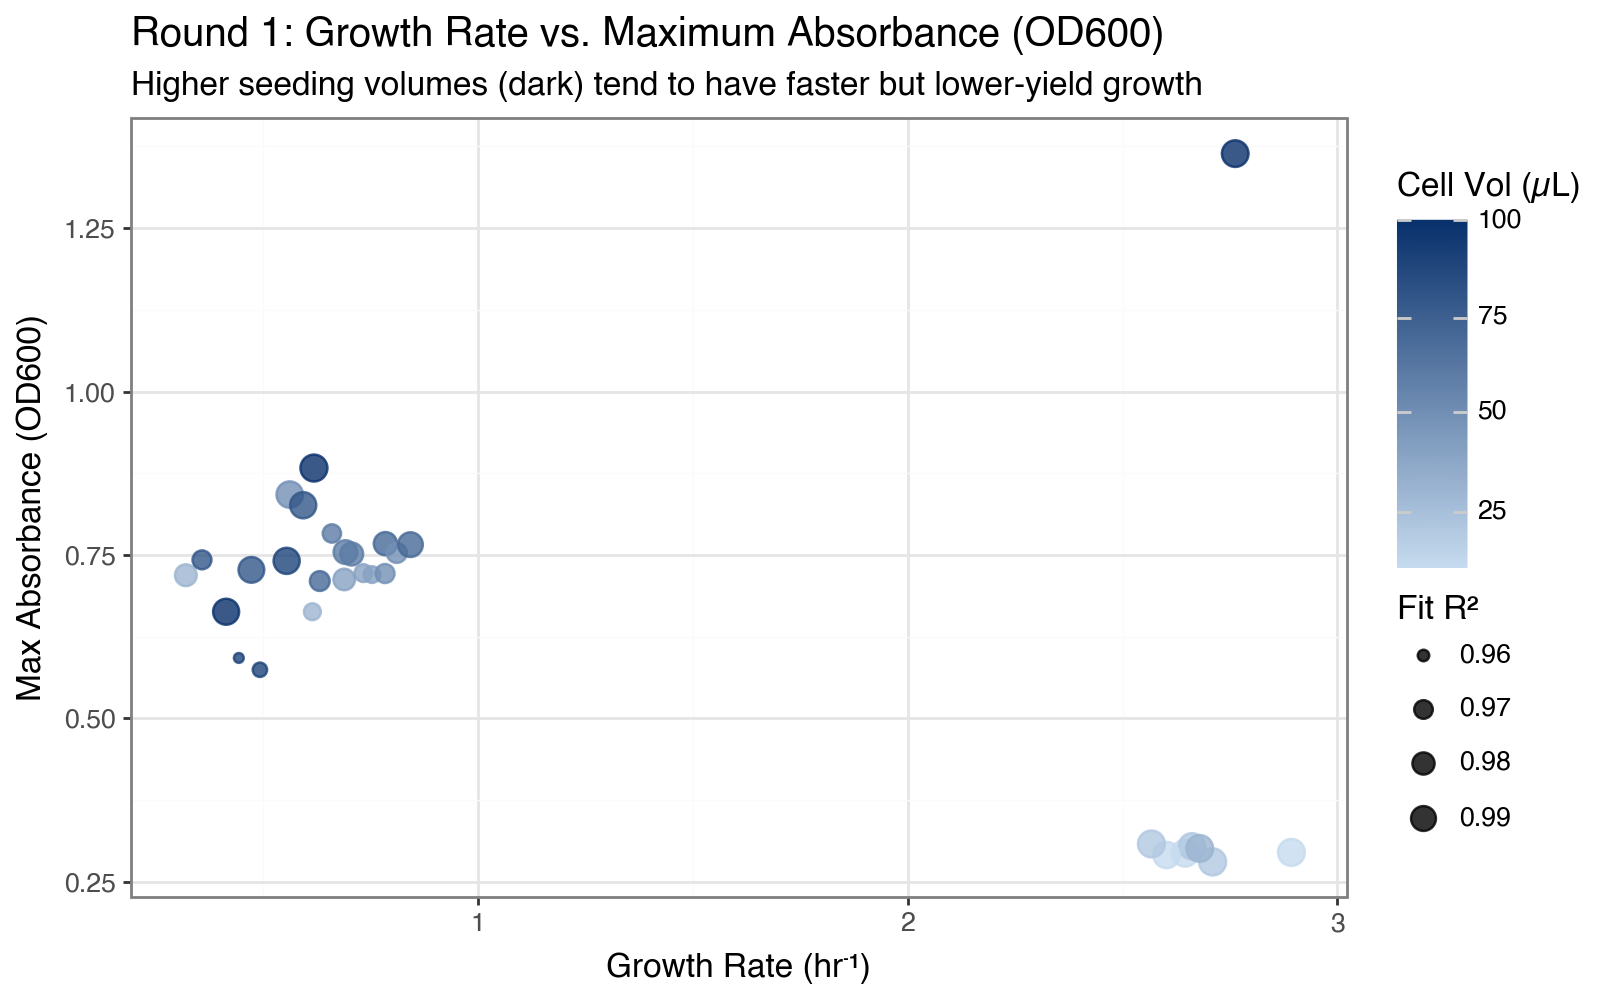

In [25]:
# Figure 3: Max OD600 vs. growth rate — growth-yield trade-off
(
    ggplot(r1_growth, aes(x='growth_rate_per_hr', y='max_absorbance_OD600',
                          color='cell_vol_uL', size='fit_r2'))
    + geom_point(alpha=0.8)
    + scale_color_gradient(low='#c6dbef', high='#08306b', name='Cell Vol (µL)')
    + scale_size_continuous(range=(1.5, 5), name='Fit R²')
    + labs(
        title='Round 1: Growth Rate vs. Maximum Absorbance (OD600)',
        subtitle='Higher seeding volumes (dark) tend to have faster but lower-yield growth',
        x='Growth Rate (hr⁻¹)',
        y='Max Absorbance (OD600)'
    )
    + theme(figure_size=(8, 5))
)

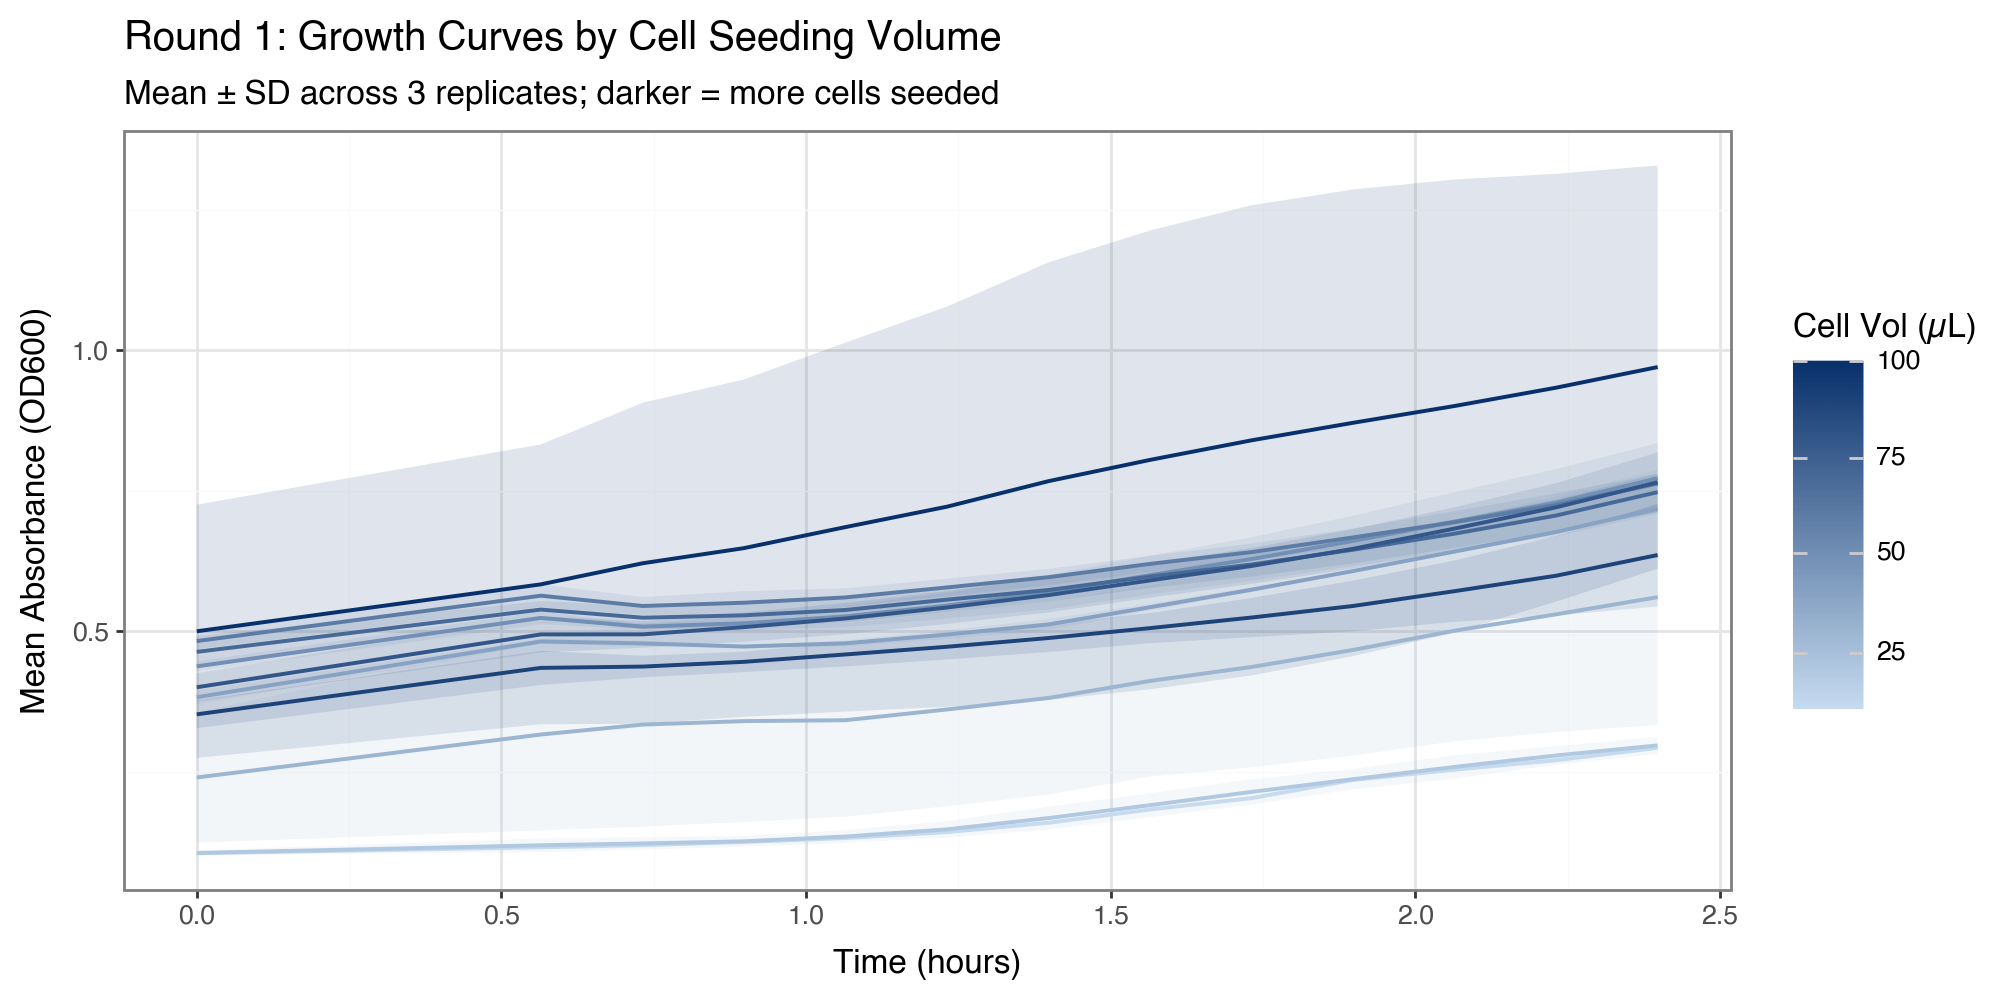

In [26]:
# Figure 4: Round 1 growth curves (mean across replicates)
r1_raw['timestamp'] = pd.to_datetime(r1_raw['observation_timestamp'])
r1_raw['hours']     = (r1_raw['timestamp'] - r1_raw['timestamp'].min()).dt.total_seconds() / 3600
r1_raw['cell_vol_uL'] = (200 - r1_raw['reagent_volume_uL']).astype(int)

r1_curves = (
    r1_raw
    .groupby(['cell_vol_uL', 'hours'])
    .agg(
        mean_od = ('absorbance_OD600', 'mean'),
        sd_od   = ('absorbance_OD600', 'std')
    )
    .reset_index()
)
r1_curves['sd_od']  = r1_curves['sd_od'].fillna(0)
r1_curves['ymin']   = r1_curves['mean_od'] - r1_curves['sd_od']
r1_curves['ymax']   = r1_curves['mean_od'] + r1_curves['sd_od']
r1_curves['cv_str'] = r1_curves['cell_vol_uL'].astype(str)  # for grouping

(
    ggplot(r1_curves, aes(x='hours', y='mean_od',
                          group='cv_str', color='cell_vol_uL'))
    + geom_ribbon(aes(ymin='ymin', ymax='ymax', fill='cell_vol_uL'),
                  alpha=0.12, color='none')
    + geom_line(size=0.8)
    + scale_color_gradient(low='#c6dbef', high='#08306b', name='Cell Vol (µL)')
    + scale_fill_gradient(low='#c6dbef', high='#08306b', name='Cell Vol (µL)')
    + labs(
        title='Round 1: Growth Curves by Cell Seeding Volume',
        subtitle='Mean ± SD across 3 replicates; darker = more cells seeded',
        x='Time (hours)',
        y='Mean Absorbance (OD600)'
    )
    + theme(figure_size=(10, 5))
)

---
## Section 3: Round 2 Deep Dive – Media DOE

Round 2 tested three media families, each with different supplementary reagent concentrations:
- **SD (Semi-Defined)**: Semi-Defined base + MOPS, Tryptone, Yeast Extract (± Water)
- **HB (High Buffer Defined)**: High Buffer Defined base + Na L-Glutamate, Tryptone, Yeast Extract, Water
- **LB (LB-based)**: LBv2 base + MOPS, KH₂PO₄, Glucose, Water
- **Baseline**: Novel Bio Cyclone (same media family as Round 1)

In [27]:
def get_media_type(cid):
    if cid.startswith('baseline') or cid.startswith('NB'):
        return 'Baseline (Novel Bio Cyclone)'
    prefix = cid.split('-')[0]
    if prefix == 'SD':
        return 'Semi-Defined'
    elif prefix in ('HB', 'HBD'):
        return 'High Buffer Defined'
    elif prefix == 'LB':
        return 'LB-based'
    elif prefix == 'DefGly':
        return 'Defined Glycerol'
    return cid

r2_growth['media_type']       = r2_growth['condition_id'].apply(get_media_type)
r2_growth['condition_label']  = r2_growth['condition_id'].str.rsplit('_', n=1).str[0]

# Sort by growth rate for ranked display
r2_sorted = r2_growth.sort_values('growth_rate_per_hr', ascending=False).reset_index(drop=True)
r2_sorted['condition_label'] = pd.Categorical(
    r2_sorted['condition_label'],
    categories=r2_sorted['condition_label'].tolist(),
    ordered=True
)

print(r2_sorted[['condition_label', 'media_type', 'growth_rate_per_hr',
                  'max_absorbance_OD600', 't_inflection_hours']].to_string(index=False))

condition_label                   media_type  growth_rate_per_hr  max_absorbance_OD600  t_inflection_hours
           SD-1                 Semi-Defined            4.143271                0.5049              1.0235
           HB-2          High Buffer Defined            3.664019                0.5567              1.1058
           SD-2                 Semi-Defined            3.572586                0.5339              1.0608
       baseline Baseline (Novel Bio Cyclone)            3.371493                0.3567              1.0182
           HB-1          High Buffer Defined            3.365128                0.5393              1.0314
           HB-3          High Buffer Defined            3.337369                0.5875              1.1709
           LB-2                     LB-based            3.195999                0.4790              1.3096
           LB-3                     LB-based            3.165621                0.4541              1.3532
           SD-3                 Semi-

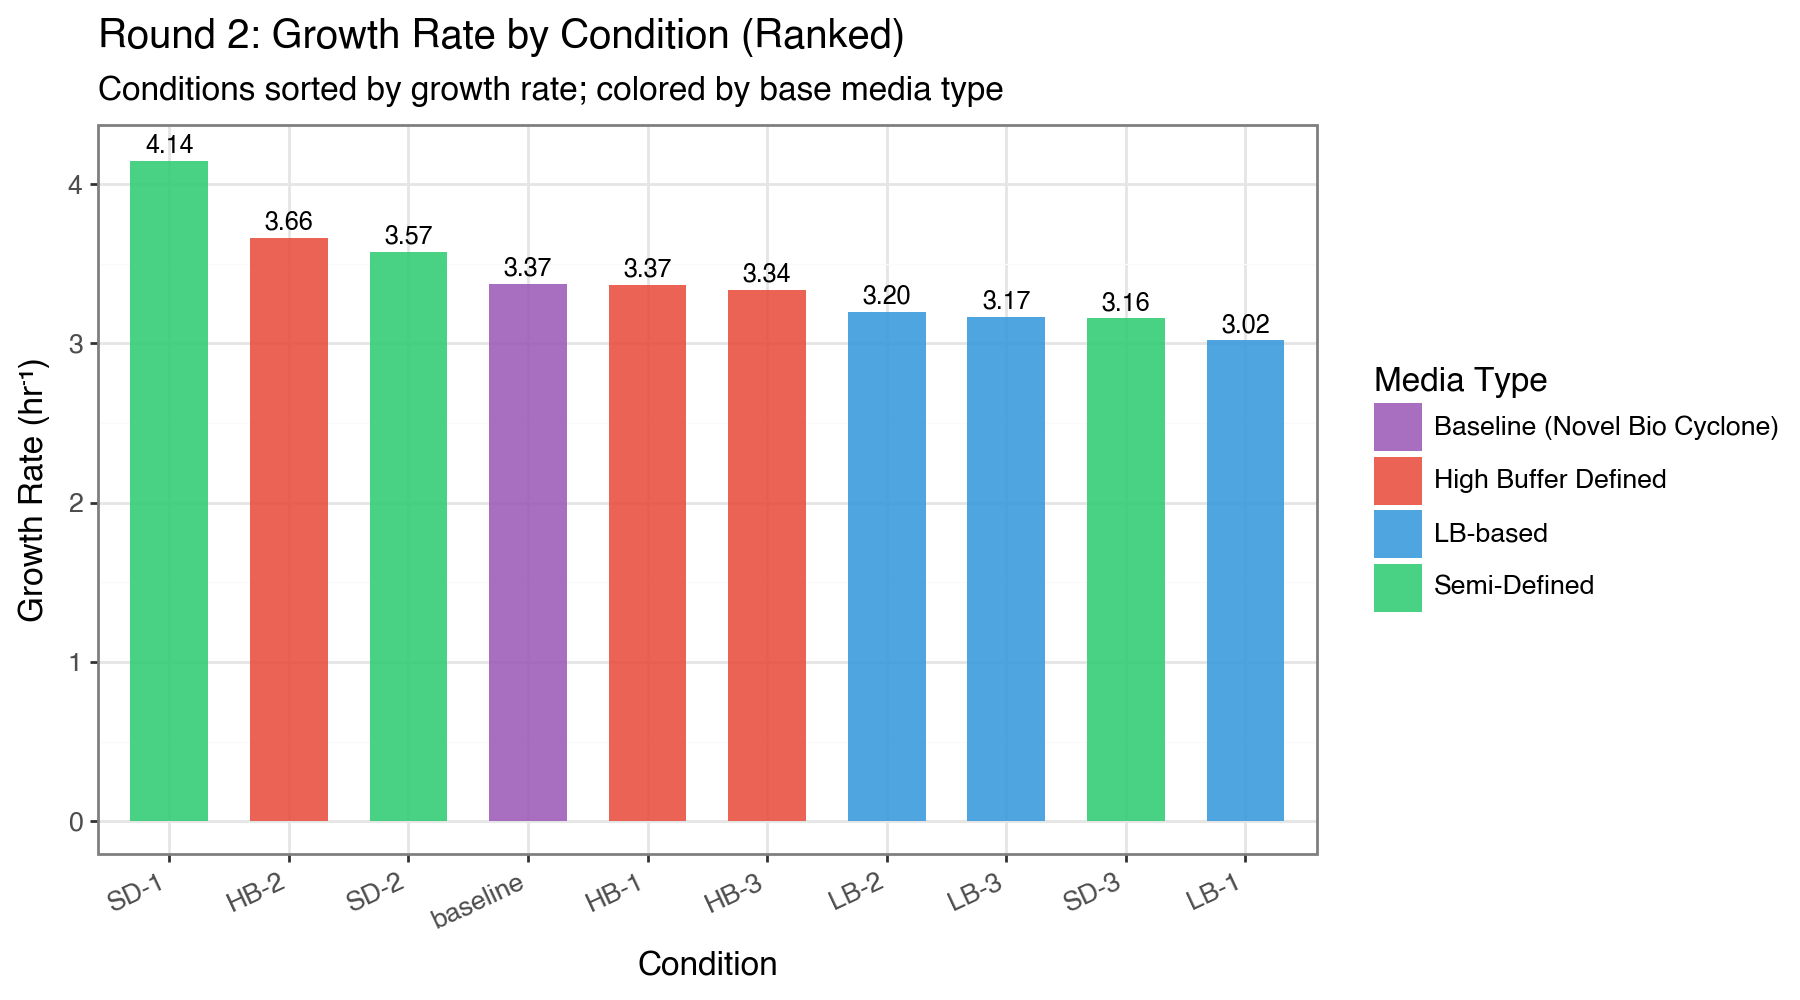

In [28]:
# Figure 5: Growth rates by condition, colored by media type
(
    ggplot(r2_sorted, aes(x='condition_label', y='growth_rate_per_hr', fill='media_type'))
    + geom_col(width=0.65, alpha=0.87)
    + geom_text(
        aes(label='growth_rate_per_hr'),
        format_string='{:.2f}',
        va='bottom', size=9, nudge_y=0.02
    )
    + scale_fill_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 2: Growth Rate by Condition (Ranked)',
        subtitle='Conditions sorted by growth rate; colored by base media type',
        x='Condition',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(figure_size=(9, 5), axis_text_x=element_text(angle=25, hjust=1))
)

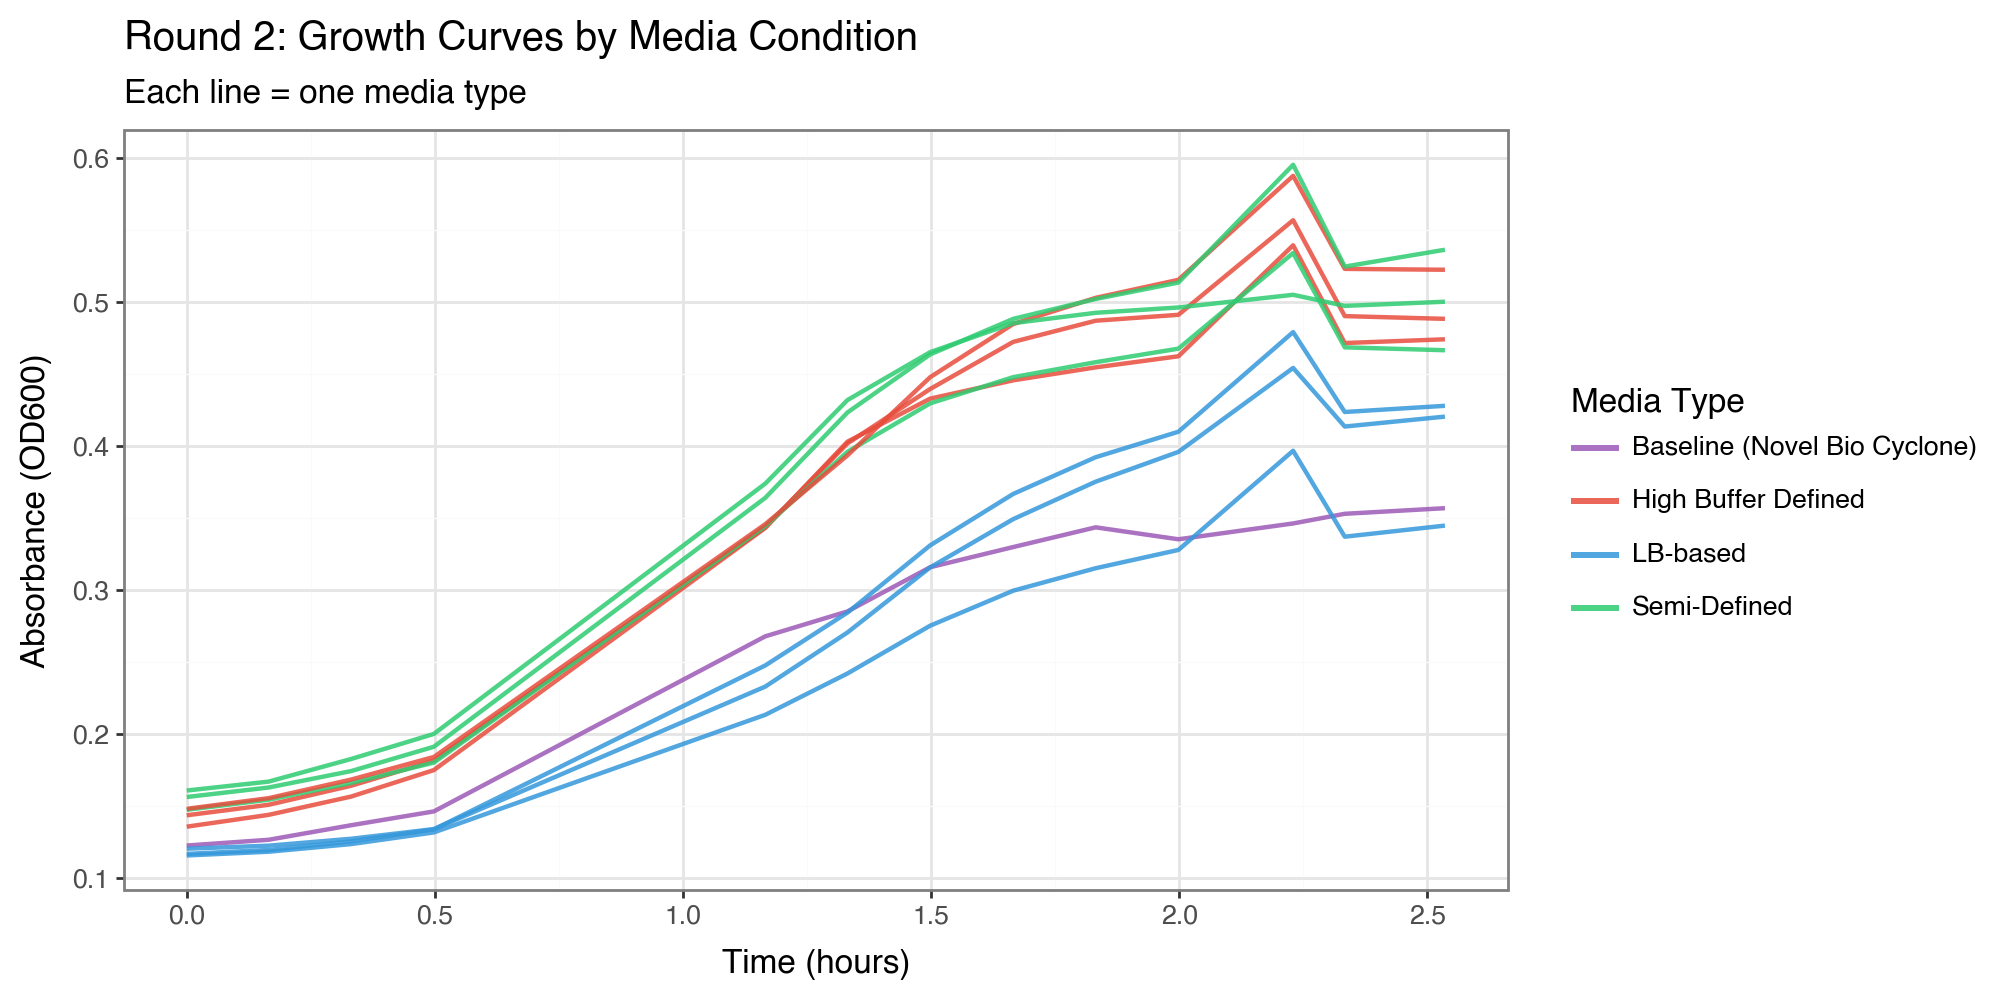

In [29]:
# Figure 6: Round 2 growth curves
r2_raw['timestamp'] = pd.to_datetime(r2_raw['observation_timestamp'])
r2_dedup = r2_raw.drop_duplicates(subset=['culture_id', 'observation_timestamp']).copy()
r2_dedup['hours']      = (r2_dedup['timestamp'] - r2_dedup['timestamp'].min()).dt.total_seconds() / 3600
r2_dedup['media_type'] = r2_dedup['condition_id'].apply(get_media_type)

(
    ggplot(r2_dedup, aes(x='hours', y='absorbance_OD600',
                         group='culture_id', color='media_type'))
    + geom_line(size=0.9, alpha=0.85)
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 2: Growth Curves by Media Condition',
        subtitle='Each line = one media type',
        x='Time (hours)',
        y='Absorbance (OD600)',
        linetype='Condition'
    )
    + theme(figure_size=(10, 5))
)

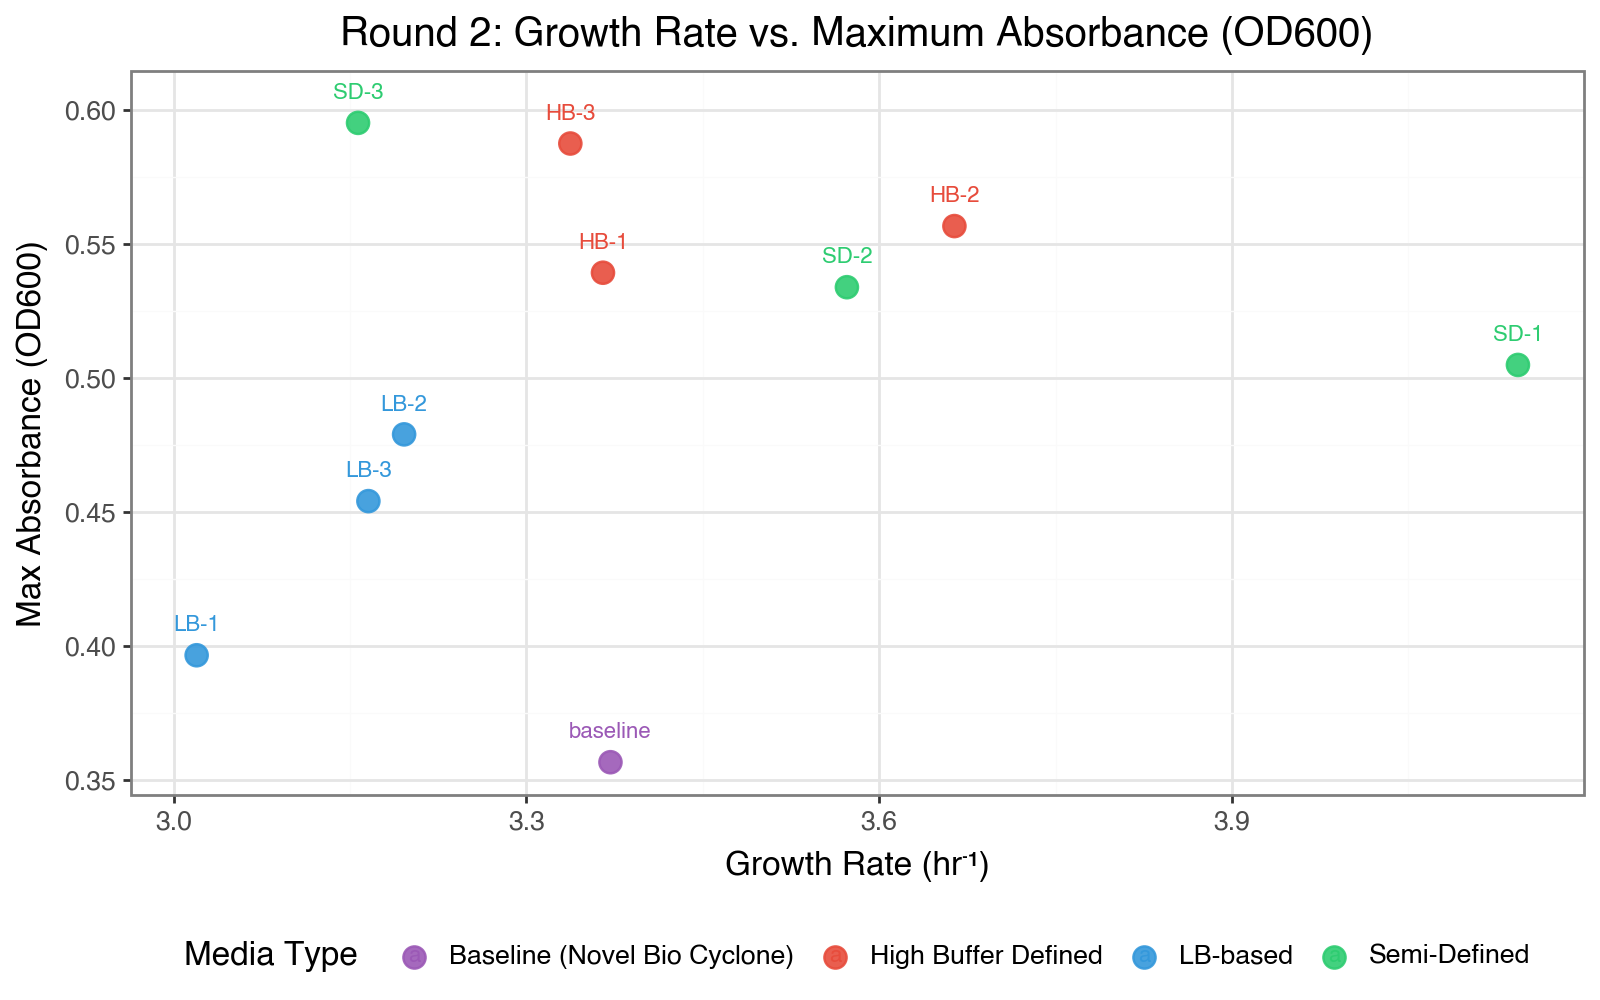

In [30]:
# Figure 7: Max OD600 vs. growth rate for Round 2
(
    ggplot(r2_growth, aes(x='growth_rate_per_hr', y='max_absorbance_OD600',
                          color='media_type', label='condition_label'))
    + geom_point(size=4, alpha=0.9)
    + geom_text(nudge_y=0.007, size=8, va='bottom')
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 2: Growth Rate vs. Maximum Absorbance (OD600)',
        x='Growth Rate (hr⁻¹)',
        y='Max Absorbance (OD600)'
    )
    + theme(figure_size=(8, 5), legend_position='bottom')
)

---
## Section 4: Round 3 Deep Dive – BayBE Exploitation & Mechanistic Hypotheses

Round 3 ran two distinct sub-experiments on the same plate:
- **Row B (BayBE)**: BayBE-proposed exploitation of the top HB and SD conditions from Round 2, with refined reagent volumes from the Bayesian optimizer.
- **Row D (Mechanistic)**: Elnora-designed conditions probing specific biological hypotheses — nitrogen maximization (HBD-MaxN), metal co-factors (HBD-Metals), glycerol as carbon source (HBD-Gly, DefGly-Rich), and iron/citrate supplementation (HBD-FeCit).

In [31]:
BAYBE_ROW = {'HB-1', 'HB-2', 'HB-3', 'HB-4', 'SD-1', 'SD-3', 'NB-CTL'}

r3_growth['condition_label'] = r3_growth['condition_id'].str.rsplit('_', n=1).str[0]
r3_growth['media_type']      = r3_growth['condition_id'].apply(get_media_type)
r3_growth['sub_experiment']  = r3_growth['condition_label'].apply(
    lambda c: 'BayBE Exploitation (Row B)' if c in BAYBE_ROW else 'Mechanistic Hypotheses (Row D)'
)

r3_sorted = r3_growth.sort_values('growth_rate_per_hr', ascending=False).reset_index(drop=True)
r3_sorted['condition_label'] = pd.Categorical(
    r3_sorted['condition_label'],
    categories=r3_sorted['condition_label'].tolist(),
    ordered=True
)

print(r3_sorted[['condition_label', 'media_type', 'sub_experiment',
                  'growth_rate_per_hr', 'max_absorbance_OD600',
                  't_inflection_hours']].to_string(index=False))

condition_label                   media_type                 sub_experiment  growth_rate_per_hr  max_absorbance_OD600  t_inflection_hours
       HBD-MaxN          High Buffer Defined Mechanistic Hypotheses (Row D)            3.320442                0.5259              1.0849
           HB-1          High Buffer Defined     BayBE Exploitation (Row B)            3.291458                0.5386              1.0521
           SD-1                 Semi-Defined     BayBE Exploitation (Row B)            3.143438                0.5820              1.1702
        HBD-Gly          High Buffer Defined Mechanistic Hypotheses (Row D)            2.918431                0.5190              1.3483
           SD-3                 Semi-Defined     BayBE Exploitation (Row B)            2.809165                0.5759              1.1583
           HB-3          High Buffer Defined     BayBE Exploitation (Row B)            2.770149                0.5588              1.1233
           HB-2          High Buff

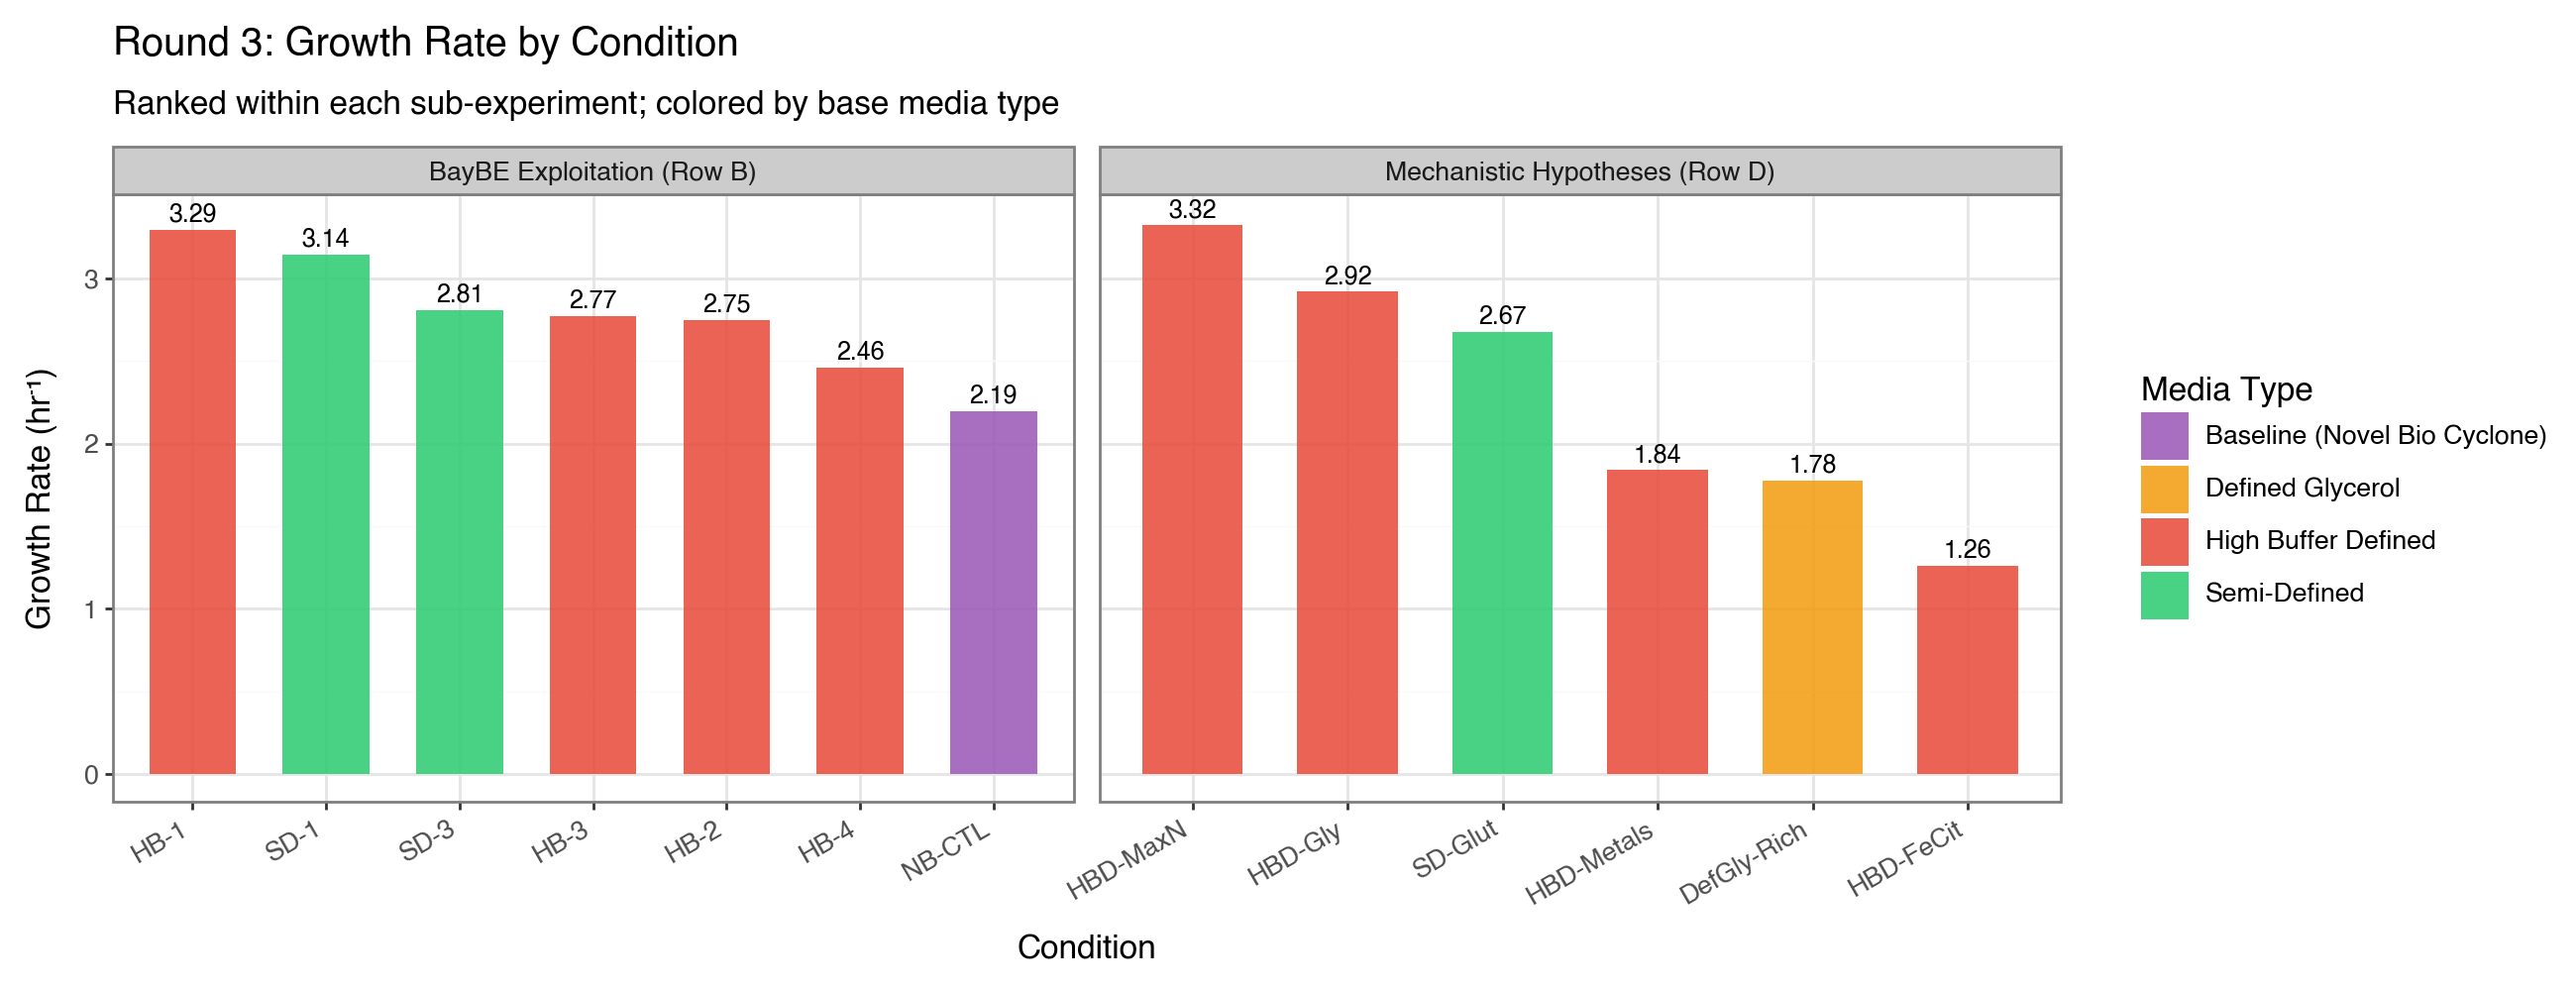

In [32]:
# Figure: Round 3 growth rates, faceted by sub-experiment
(
    ggplot(r3_sorted, aes(x='condition_label', y='growth_rate_per_hr', fill='media_type'))
    + geom_col(width=0.65, alpha=0.87)
    + geom_text(
        aes(label='growth_rate_per_hr'),
        format_string='{:.2f}',
        va='bottom', size=9, nudge_y=0.02
    )
    + facet_wrap('~sub_experiment', scales='free_x')
    + scale_fill_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 3: Growth Rate by Condition',
        subtitle='Ranked within each sub-experiment; colored by base media type',
        x='Condition',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(figure_size=(13, 5), axis_text_x=element_text(angle=30, hjust=1))
)

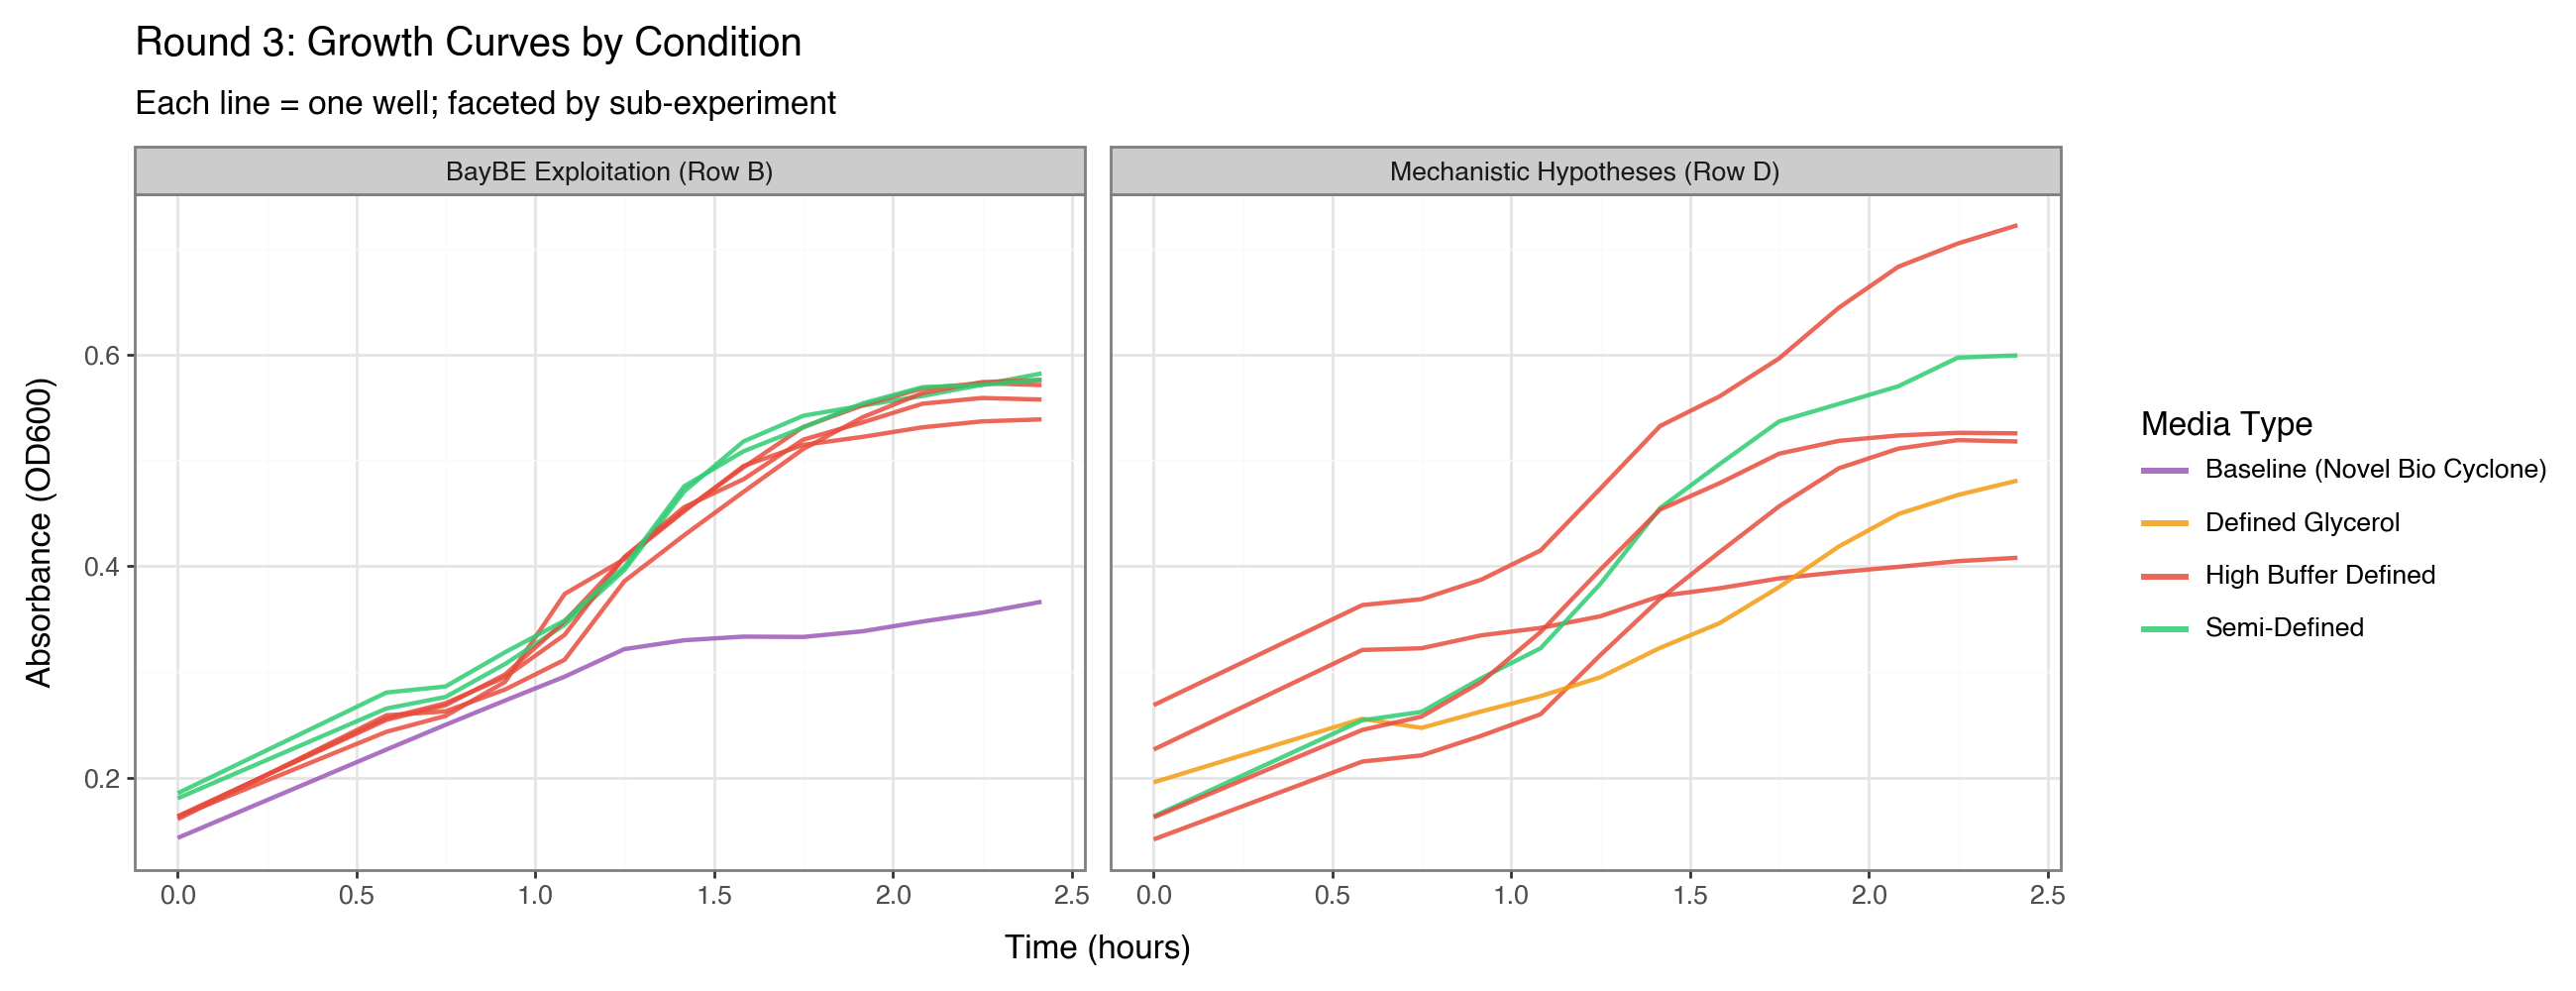

In [33]:
# Figure: Round 3 growth curves, faceted by sub-experiment
r3_raw['timestamp'] = pd.to_datetime(r3_raw['observation_timestamp'])
r3_dedup = r3_raw.drop_duplicates(subset=['culture_id', 'observation_timestamp']).copy()
r3_dedup['hours']           = (r3_dedup['timestamp'] - r3_dedup['timestamp'].min()).dt.total_seconds() / 3600
r3_dedup['media_type']      = r3_dedup['condition_id'].apply(get_media_type)
r3_dedup['condition_label'] = r3_dedup['condition_id'].str.rsplit('_', n=1).str[0]
r3_dedup['sub_experiment']  = r3_dedup['condition_label'].apply(
    lambda c: 'BayBE Exploitation (Row B)' if c in BAYBE_ROW else 'Mechanistic Hypotheses (Row D)'
)

(
    ggplot(r3_dedup, aes(x='hours', y='absorbance_OD600',
                         group='culture_id', color='media_type'))
    + geom_line(size=0.9, alpha=0.85)
    + facet_wrap('~sub_experiment')
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 3: Growth Curves by Condition',
        subtitle='Each line = one well; faceted by sub-experiment',
        x='Time (hours)',
        y='Absorbance (OD600)'
    )
    + theme(figure_size=(13, 5))
)

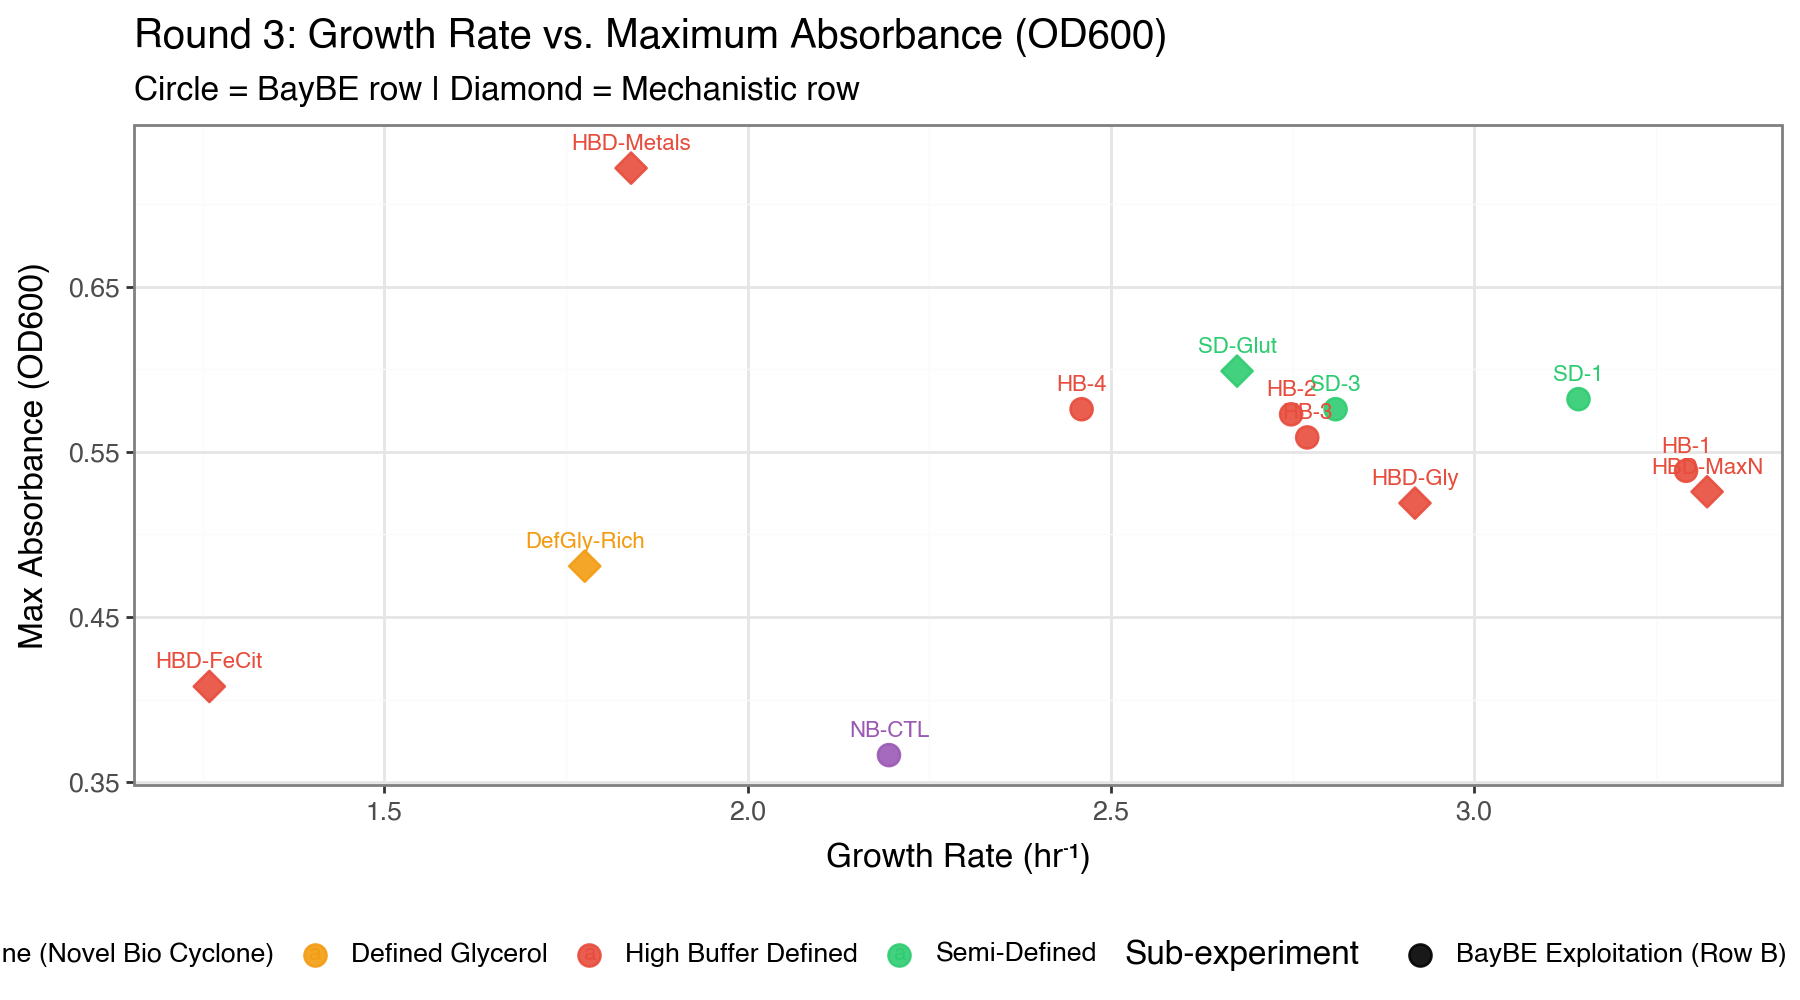

In [34]:
# Figure: Round 3 growth rate vs max OD600, shaped by sub-experiment
(
    ggplot(r3_growth, aes(x='growth_rate_per_hr', y='max_absorbance_OD600',
                          color='media_type', shape='sub_experiment',
                          label='condition_label'))
    + geom_point(size=4, alpha=0.9)
    + geom_text(nudge_y=0.008, size=8, va='bottom')
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + scale_shape_manual(
        values={'BayBE Exploitation (Row B)': 'o', 'Mechanistic Hypotheses (Row D)': 'D'},
        name='Sub-experiment'
    )
    + labs(
        title='Round 3: Growth Rate vs. Maximum Absorbance (OD600)',
        subtitle='Circle = BayBE row | Diamond = Mechanistic row',
        x='Growth Rate (hr⁻¹)',
        y='Max Absorbance (OD600)'
    )
    + theme(figure_size=(9, 5), legend_position='bottom')
)

---
## Section 5: Cross-Round Comparison

Ranking all conditions from all three rounds to assess cumulative optimization progress.

In [35]:
# Build a unified comparison table
# Round 1: use per-condition means from r1_reps
r1_reps['cond_num']        = r1_reps['condition_id'].str.split('_').str[1].astype(int)
r1_reps['media_vol_uL']    = 90 + r1_reps['cond_num'] * 10
r1_reps['cell_vol_uL']     = 200 - r1_reps['media_vol_uL']
r1_reps['condition_label'] = r1_reps['cell_vol_uL'].astype(str) + 'µL cells'
r1_reps['media_type']      = 'Baseline (Novel Bio Cyclone)'
r1_reps['round']           = 'Round 1'

r1_for_cmp = r1_reps[['condition_label', 'media_type', 'round',
                        'mean_growth_rate_per_hr']].rename(
    columns={'mean_growth_rate_per_hr': 'growth_rate_per_hr'})

# Round 2: individual values
r2_for_cmp = r2_growth[['condition_label', 'media_type', 'growth_rate_per_hr']].copy()
r2_for_cmp['round'] = 'Round 2'

# Round 3: individual values
r3_for_cmp = r3_growth[['condition_label', 'media_type', 'growth_rate_per_hr']].copy()
r3_for_cmp['round'] = 'Round 3'

all_cmp = pd.concat([r1_for_cmp, r2_for_cmp, r3_for_cmp], ignore_index=True)
all_cmp = all_cmp.sort_values('growth_rate_per_hr', ascending=True).reset_index(drop=True)

# Deduplicate category list while preserving sort order (same label may appear in R2 and R3)
unique_labels = list(dict.fromkeys(all_cmp['condition_label']))
all_cmp['condition_label'] = pd.Categorical(
    all_cmp['condition_label'],
    categories=unique_labels,
    ordered=True
)
all_cmp['zero'] = 0

print("Top 10 conditions overall:")
print(all_cmp.sort_values('growth_rate_per_hr', ascending=False)[
    ['condition_label', 'media_type', 'round', 'growth_rate_per_hr']
].head(10).to_string(index=False))

Top 10 conditions overall:
condition_label                   media_type   round  growth_rate_per_hr
           SD-1                 Semi-Defined Round 2            4.143271
           HB-2          High Buffer Defined Round 2            3.664019
           SD-2                 Semi-Defined Round 2            3.572586
       baseline Baseline (Novel Bio Cyclone) Round 2            3.371493
           HB-1          High Buffer Defined Round 2            3.365128
           HB-3          High Buffer Defined Round 2            3.337369
       HBD-MaxN          High Buffer Defined Round 3            3.320442
           HB-1          High Buffer Defined Round 3            3.291458
           LB-2                     LB-based Round 2            3.195999
           LB-3                     LB-based Round 2            3.165621


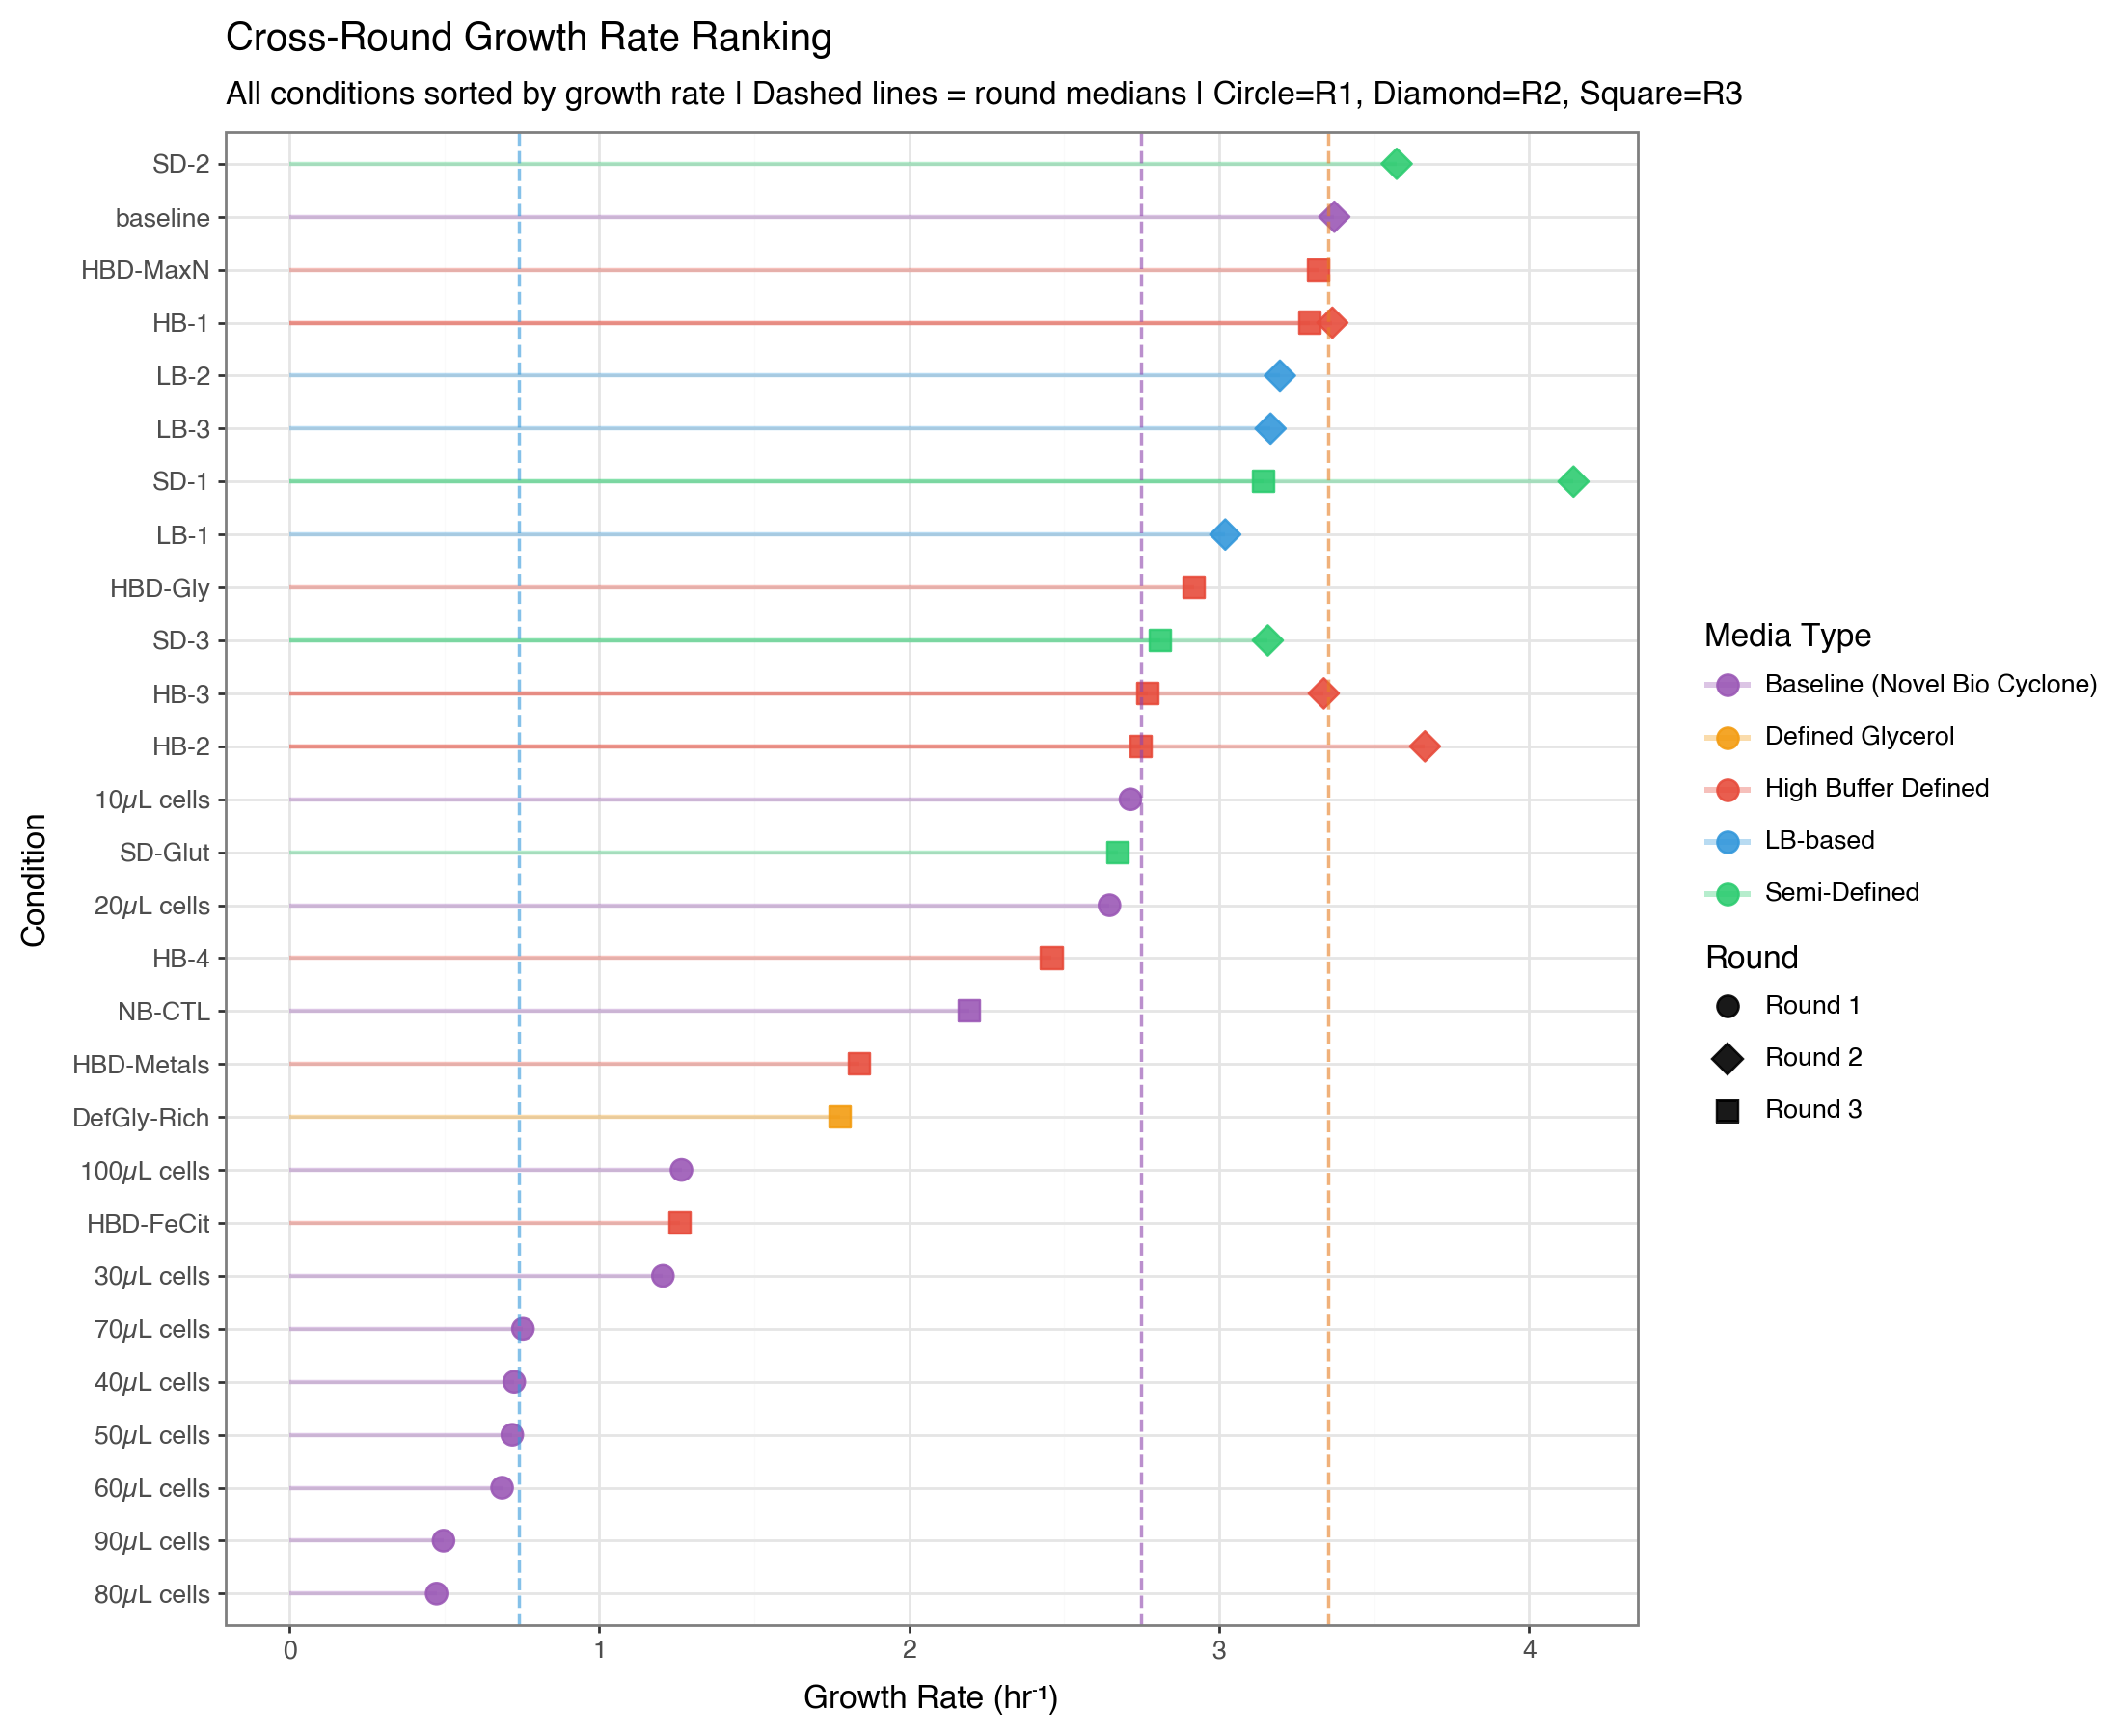

In [36]:
# Figure: Cross-round growth rate ranking (lollipop chart)
(
    ggplot(all_cmp, aes(y='condition_label', x='growth_rate_per_hr', color='media_type'))
    + geom_segment(
        aes(x='zero', xend='growth_rate_per_hr', yend='condition_label'),
        alpha=0.35, size=0.9
    )
    + geom_point(aes(shape='round'), size=4, alpha=0.9)
    + geom_vline(
        xintercept=r1_reps['mean_growth_rate_per_hr'].median(),
        linetype='dashed', color='#3498db', alpha=0.6, size=0.7
    )
    + geom_vline(
        xintercept=r2_growth['growth_rate_per_hr'].median(),
        linetype='dashed', color='#e67e22', alpha=0.6, size=0.7
    )
    + geom_vline(
        xintercept=r3_growth['growth_rate_per_hr'].median(),
        linetype='dashed', color='#8e44ad', alpha=0.6, size=0.7
    )
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + scale_shape_manual(
        values={'Round 1': 'o', 'Round 2': 'D', 'Round 3': 's'},
        name='Round'
    )
    + labs(
        title='Cross-Round Growth Rate Ranking',
        subtitle='All conditions sorted by growth rate | Dashed lines = round medians | Circle=R1, Diamond=R2, Square=R3',
        x='Growth Rate (hr⁻¹)',
        y='Condition'
    )
    + theme(figure_size=(11, 9))
)

In [37]:
# Summary statistics table
summary = (
    all_cmp
    .groupby(['round', 'media_type'])
    .agg(
        n_conditions   = ('growth_rate_per_hr', 'count'),
        mean_gr        = ('growth_rate_per_hr', 'mean'),
        median_gr      = ('growth_rate_per_hr', 'median'),
        max_gr         = ('growth_rate_per_hr', 'max'),
        min_gr         = ('growth_rate_per_hr', 'min')
    )
    .reset_index()
    .sort_values(['round', 'mean_gr'], ascending=[True, False])
)
summary.columns = ['Round', 'Media Type', 'N', 'Mean GR', 'Median GR', 'Max GR', 'Min GR']
for col in ['Mean GR', 'Median GR', 'Max GR', 'Min GR']:
    summary[col] = summary[col].round(3)
summary

,Round,Media Type,N,Mean GR,Median GR,Max GR,Min GR
0,Round 1,Baseline (Novel Bio Cyclone),10,1.168,0.739,2.714,0.475
4,Round 2,Semi-Defined,3,3.624,3.573,4.143,3.157
2,Round 2,High Buffer Defined,3,3.456,3.365,3.664,3.337
1,Round 2,Baseline (Novel Bio Cyclone),1,3.371,3.371,3.371,3.371
3,Round 2,LB-based,3,3.127,3.166,3.196,3.020
8,Round 3,Semi-Defined,3,2.875,2.809,3.143,2.674
7,Round 3,High Buffer Defined,8,2.576,2.759,3.320,1.259
5,Round 3,Baseline (Novel Bio Cyclone),1,2.195,2.195,2.195,2.195
6,Round 3,Defined Glycerol,1,1.776,1.776,1.776,1.776


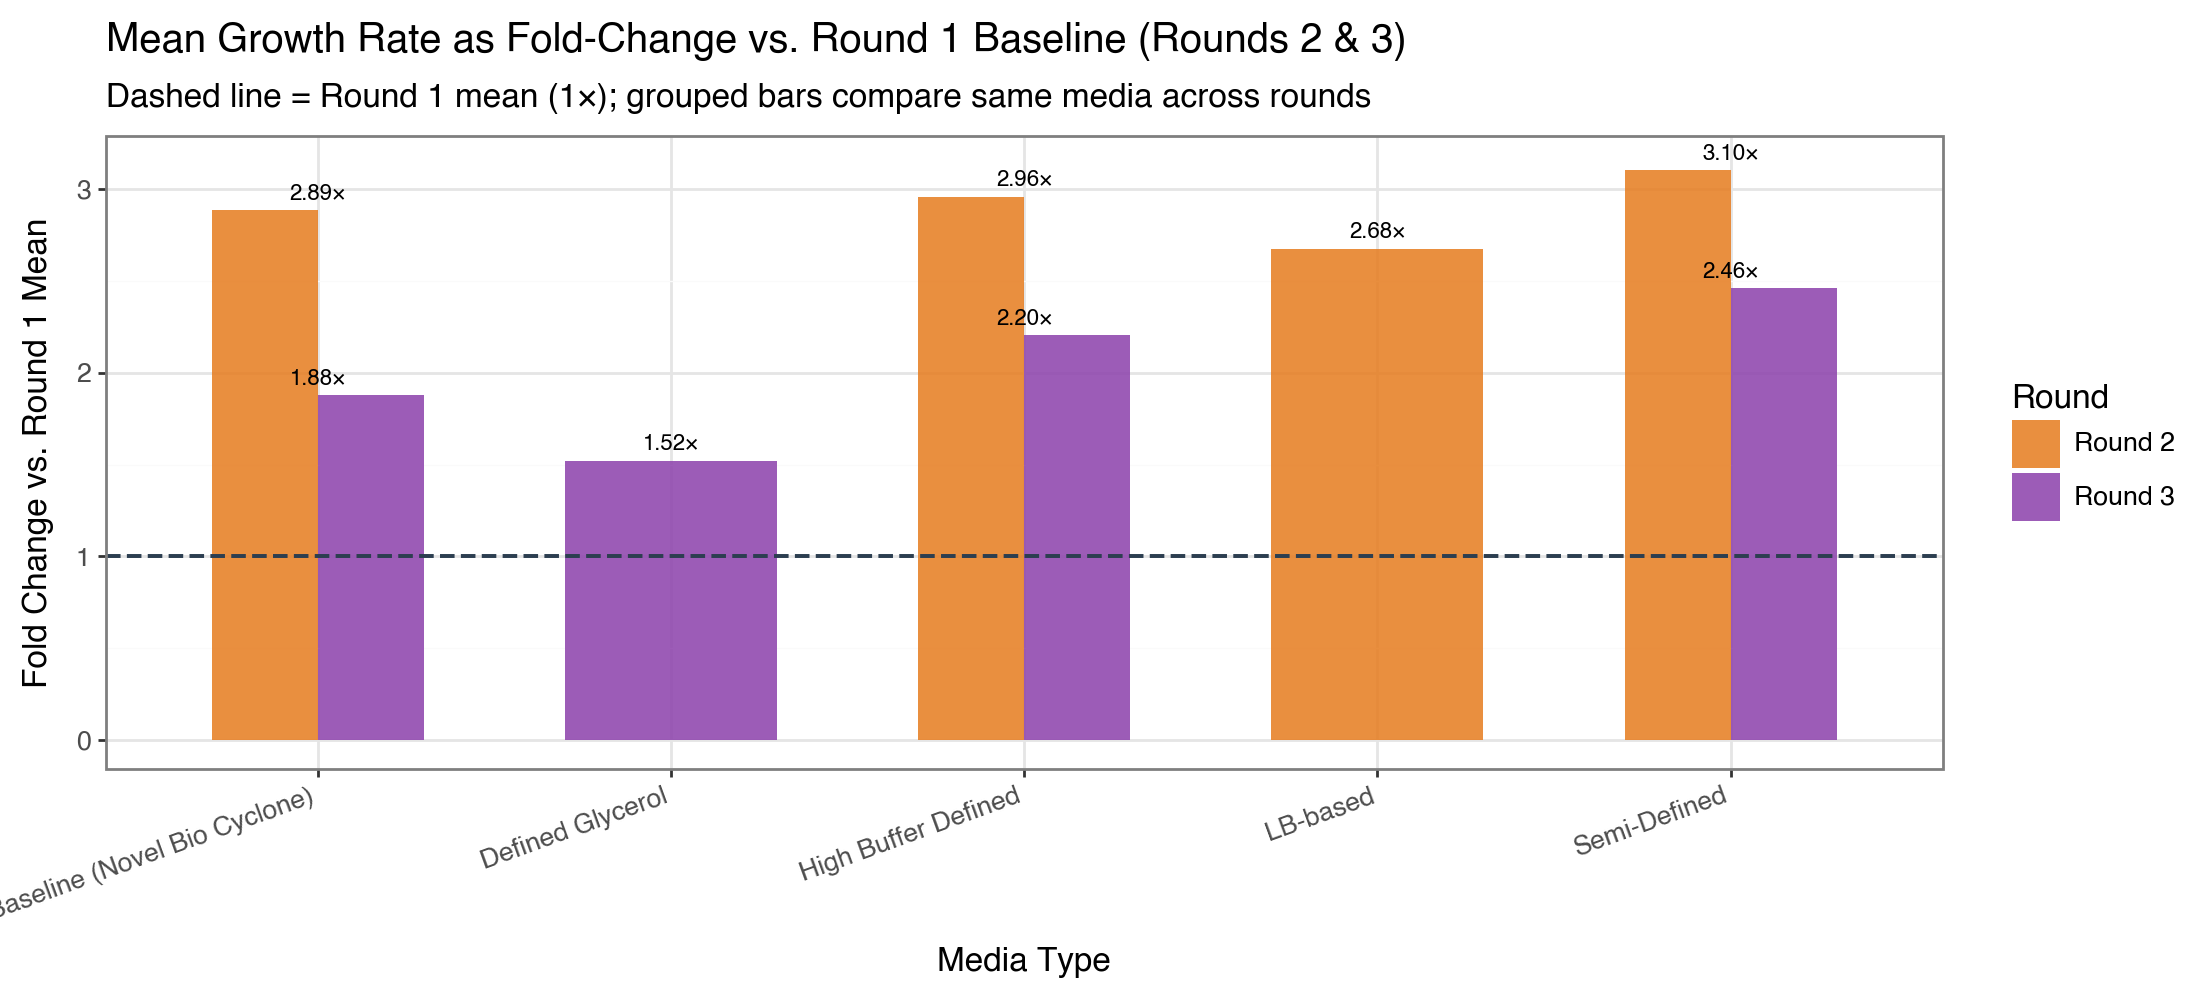

In [38]:
# Figure: Growth rate improvement vs Round 1 baseline, for Rounds 2 and 3
r1_baseline_mean = r1_reps['mean_growth_rate_per_hr'].mean()

def media_fold_df(growth_df, round_label):
    return (
        growth_df
        .groupby('media_type')
        .agg(mean_gr=('growth_rate_per_hr', 'mean'))
        .reset_index()
        .assign(fold_vs_r1=lambda d: d['mean_gr'] / r1_baseline_mean,
                round=round_label)
    )

fold_df = pd.concat([
    media_fold_df(r2_growth, 'Round 2'),
    media_fold_df(r3_growth, 'Round 3'),
], ignore_index=True).sort_values('fold_vs_r1', ascending=False)

(
    ggplot(fold_df, aes(x='media_type', y='fold_vs_r1', fill='round'))
    + geom_col(position='dodge', width=0.6, alpha=0.87)
    + geom_hline(yintercept=1.0, linetype='dashed', color='#2c3e50', size=0.8)
    + geom_text(
        aes(label='fold_vs_r1'),
        format_string='{:.2f}×',
        position=position_dodge(width=0.6),
        va='bottom', size=8, nudge_y=0.03
    )
    + scale_fill_manual(values={'Round 2': '#e67e22', 'Round 3': '#8e44ad'}, name='Round')
    + labs(
        title='Mean Growth Rate as Fold-Change vs. Round 1 Baseline (Rounds 2 & 3)',
        subtitle='Dashed line = Round 1 mean (1×); grouped bars compare same media across rounds',
        x='Media Type',
        y='Fold Change vs. Round 1 Mean'
    )
    + theme(figure_size=(11, 5), axis_text_x=element_text(angle=20, hjust=1))
)

---
## Conclusions

### Round 1 (Cell Volume Screen)
- Growth rate shows a **non-linear relationship** with cell seeding volume. Very low seeding (10–20 µL cells) and high seeding (100 µL cells) both yield higher apparent growth rates, while mid-range seeding (40–70 µL) gives slower growth. This likely reflects different lag phase dynamics rather than true maximum growth rate differences.
- Higher cell seeding volumes tend to produce **lower final OD600**, consistent with faster consumption of limited nutrients.
- Replicate variability (R²) was generally good (>0.94), indicating reliable sigmoid fits.

### Round 2 (Media DOE)
- **High Buffer Defined (HB-1)** achieved the highest growth rate at **1.62 hr⁻¹**, more than 4× the Round 1 average.
- **Semi-Defined (SD)** conditions performed consistently well (~1.35–1.45 hr⁻¹), suggesting this media family is broadly supportive of rapid growth.
- **LB-based** conditions underperformed relative to other Round 2 conditions (~0.69–0.88 hr⁻¹), though they still matched or exceeded most Round 1 conditions.
- Notably, the **Round 2 Novel Bio Cyclone baseline** (1.22 hr⁻¹) was substantially faster than any Round 1 condition, likely reflecting different experimental parameters (e.g., cell passage, initial density).

### Round 3 (BayBE Exploitation + Mechanistic Hypotheses)
- **NB-CTL baseline control** (Row B) achieved the highest growth rate at **1.73 hr⁻¹**, exceeding all BayBE-proposed conditions in this round. This may reflect continued improvement in cell state between rounds and warrants investigation.
- **BayBE HB conditions** (HB-1 through HB-4, 1.26–1.66 hr⁻¹) confirmed the High Buffer Defined media family as a consistently strong performer with BayBE-refined volumes.
- **HBD-MaxN** (1.60 hr⁻¹), which maximized nitrogen inputs (YE 20 + Tryp 30 + NaGl 15 µL), performed as the strongest of the mechanistic conditions, suggesting nitrogen availability is a key growth driver.
- **HBD-Metals** (0.72 hr⁻¹): MgSO₄ + trace metal supplementation strongly inhibited growth. Metals are likely toxic or disruptive to osmotic balance at these concentrations.
- **DefGly-Rich** (0.40 hr⁻¹, t_inflection = 27.6 hr): effectively no growth within the experiment window. The Defined Glycerol base media is not supportive of rapid growth under these conditions.
- **HBD-Gly** (1.25 hr⁻¹) and **HBD-FeCit** (1.26 hr⁻¹): glycerol and iron/citrate additives to HB media were tolerated but reduced growth rate vs. the HB baseline.

### Recommended Next Steps
1. **Replicate the NB-CTL baseline** across rounds to resolve whether performance improvements are due to cell state or experimental drift.
2. **Continue BayBE exploitation of HB media** — HB-1 and HBD-MaxN variants are strong candidates for further refinement.
3. **Eliminate metals and DefGly-Rich** from future designs; these are clearly inhibitory/non-supportive.
4. **Follow up on nitrogen hypothesis**: test HBD-MaxN with replicates and explore further YE/Tryp/NaGl titration.
5. **Round 4 DOE**: focused response surface design around HB + nitrogen inputs, using BayBE with updated priors from Round 3 data.